# Data load and EDA

## Methodology overview

Pipeline consists of four stages:
1. **Data preprocessing**: EDA, exposure filtering,
   outlier clipping, log-transformation of Density, OHE of categorical features
2. **Baseline models:** GLMs - Poisson, NB, ZIP, ZINB to capture linear effects. Tree-based ensembles - Random Forest (bagging) and XGBoost (boosting) with optuna-based hyperparameter tuning.
4. **Final model - stacking ensemble**: 5-fold OOF predictions of ZIP + RF + XGBoost combined via Ridge meta-model.

Performance is evaluated by Test poisson deviance, MAE, and Gini with SHAP analysis for interpretability.

In [5]:
!pip install optuna

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
import xgboost as xgb
import optuna
from sklearn.ensemble import RandomForestRegressor
import time
from sklearn.model_selection import KFold
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Ridge
import shap
from matplotlib.patches import Patch

In [7]:
df = pd.read_csv("freMTPL2freq.csv")
print(f"Dataset size: {df.shape[0]:,} strings and {df.shape[1]} columns")

Dataset size: 678,013 strings and 12 columns


In [8]:
df.head(5)

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


In [9]:
cat_cols  = ["Area", "VehBrand", "VehGas", "Region"]
num_cols  = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]
print("Numerical features:")
print(df[["ClaimNb","Exposure"] + num_cols].describe().round(4).to_string())

print("\nCategorical features:")
for c in cat_cols:
    print(f"{c}: {df[c].nunique()} unique values")

print("\nMissing values:")
print(df.isnull().sum())

Numerical features:
           ClaimNb     Exposure     VehPower       VehAge      DrivAge   BonusMalus      Density
count  678013.0000  678013.0000  678013.0000  678013.0000  678013.0000  678013.0000  678013.0000
mean        0.0532       0.5288       6.4546       7.0443      45.4991      59.7615    1792.4224
std         0.2401       0.3644       2.0509       5.6662      14.1374      15.6367    3958.6466
min         0.0000       0.0027       4.0000       0.0000      18.0000      50.0000       1.0000
25%         0.0000       0.1800       5.0000       2.0000      34.0000      50.0000      92.0000
50%         0.0000       0.4900       6.0000       6.0000      44.0000      50.0000     393.0000
75%         0.0000       0.9900       7.0000      11.0000      55.0000      64.0000    1658.0000
max        16.0000       2.0100      15.0000     100.0000     100.0000     230.0000   27000.0000

Categorical features:
Area: 6 unique values
VehBrand: 11 unique values
VehGas: 2 unique values
Region: 22 

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10000,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77000,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75000,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09000,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84000,B,7,0,46,50,B12,Diesel,76,R72
...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,E,4,0,54,50,B12,Regular,3317,R93
678009,6114327.0,0,0.00274,E,4,0,41,95,B12,Regular,9850,R11
678010,6114328.0,0,0.00274,D,6,2,45,50,B12,Diesel,1323,R82
678011,6114329.0,0,0.00274,B,4,0,60,50,B12,Regular,95,R26


## Target variable (Claims)

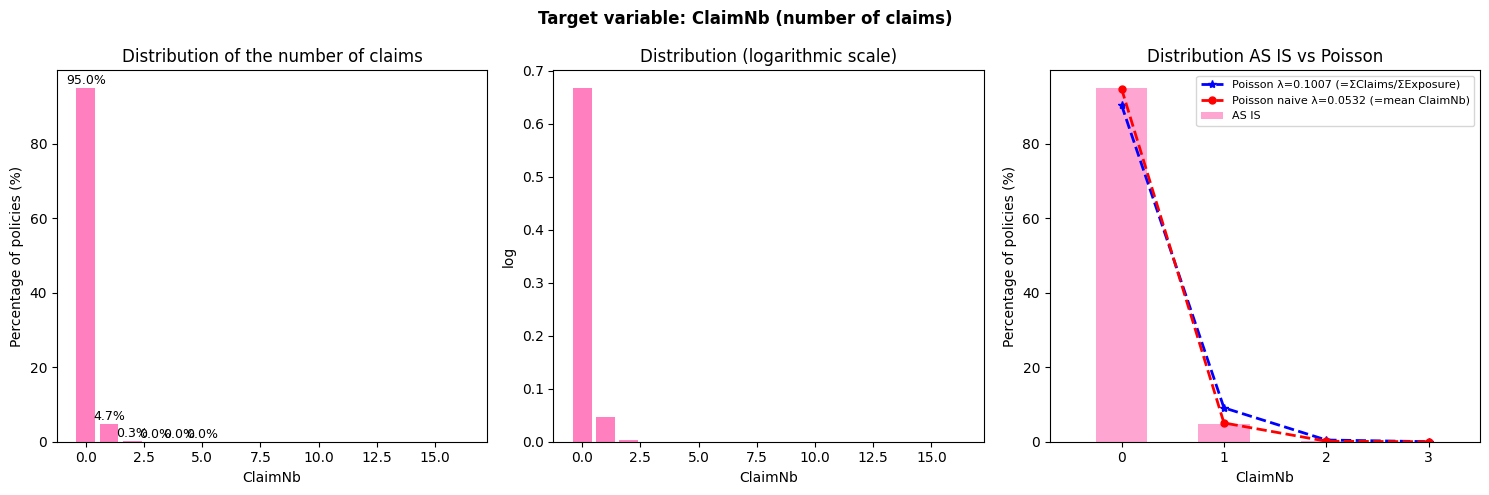

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Target variable: ClaimNb (number of claims)", fontweight="bold")

counts = df["ClaimNb"].value_counts().sort_index()
zero_rate = (df["ClaimNb"] == 0).mean()

# Subplot 1: ClaimNb distribution
axes[0].bar(counts.index, counts.values / len(df) * 100, color='hotpink', alpha=0.85)
axes[0].set_xlabel("ClaimNb")
axes[0].set_ylabel("Percentage of policies (%)")
axes[0].set_title("Distribution of the number of claims")
for k, v in zip(counts.index[:6], counts.values[:6]):
  axes[0].text(k, v / len(df) * 100 + 0.3, f"{v/len(df)*100:.1f}%", ha="center", va="bottom", fontsize=9)

# Subplot 2: Log-scale distribution
log_counts = np.log1p(counts.values / len(df))
axes[1].bar(counts.index, log_counts, color='hotpink', alpha=0.85)
axes[1].set_xlabel("ClaimNb")
axes[1].set_ylabel("log")
axes[1].set_title("Distribution (logarithmic scale)")

# Subplot 3: Distribution AS IS vs Poisson
mean_claim = df["ClaimNb"].mean()
var_claim = df["ClaimNb"].var()
lambda_correct = df["ClaimNb"].sum() / df["Exposure"].sum()

max_k = int(df[df["ClaimNb"] > 0]["ClaimNb"].quantile(0.99))+ 1
x_range = np.arange(0, max_k + 1)

obs_pct = np.array([counts.get(k, 0) / len(df) * 100 for k in x_range])
poisson_naive = stats.poisson.pmf(x_range, mean_claim) * 100
poisson_correct = stats.poisson.pmf(x_range, lambda_correct) * 100

axes[2].bar(x_range, obs_pct, width=0.5,
            color="hotpink", alpha=0.6,
            label="AS IS")
axes[2].plot(x_range, poisson_correct, "*--", color="blue", linewidth=2,
             markersize=6,
             label=f"Poisson λ={lambda_correct:.4f} (=ΣClaims/ΣExposure)")
axes[2].plot(x_range, poisson_naive, "o--",
             color="red", linewidth=2,
             markersize=5,
             label=f"Poisson naive λ={mean_claim:.4f} (=mean ClaimNb)")
axes[2].set_xlim(-0.7, max_k + 0.5)
axes[2].set_xticks(x_range)
axes[2].set_xlabel("ClaimNb")
axes[2].set_ylabel("Percentage of policies (%)")
axes[2].set_title("Distribution AS IS vs Poisson")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

* Data are highly zero-inflated (around 95% of zeros), this motivates to use ZIP or ZINB models
Variance exceeds mean (overdispersion)

* Naive Poisson underestimates claim frequency (red line shifted to the left on the plot), this shows that exposure must be included (offset)

* But even exposure-adjusted Poisson provides poor fit (fails to capture both zero mass and tail behavior)

* Data exhibit rare but extreme claim counts (max = 16), insight: tree-based models (RF, XGBoost) may capture this better

In [13]:
print("Mean:", mean_claim)
print("Variance:", var_claim)
print("Var/Mean:", var_claim / mean_claim)

Mean: 0.05324676665491664
Variance: 0.05765633238094156
Var/Mean: 1.0828137744889295


* Variance exceeds mean (overdispersion is captured) and that means that Poisson assumptions are violated (var = mean) -> NB is more appropriate

## Exposure

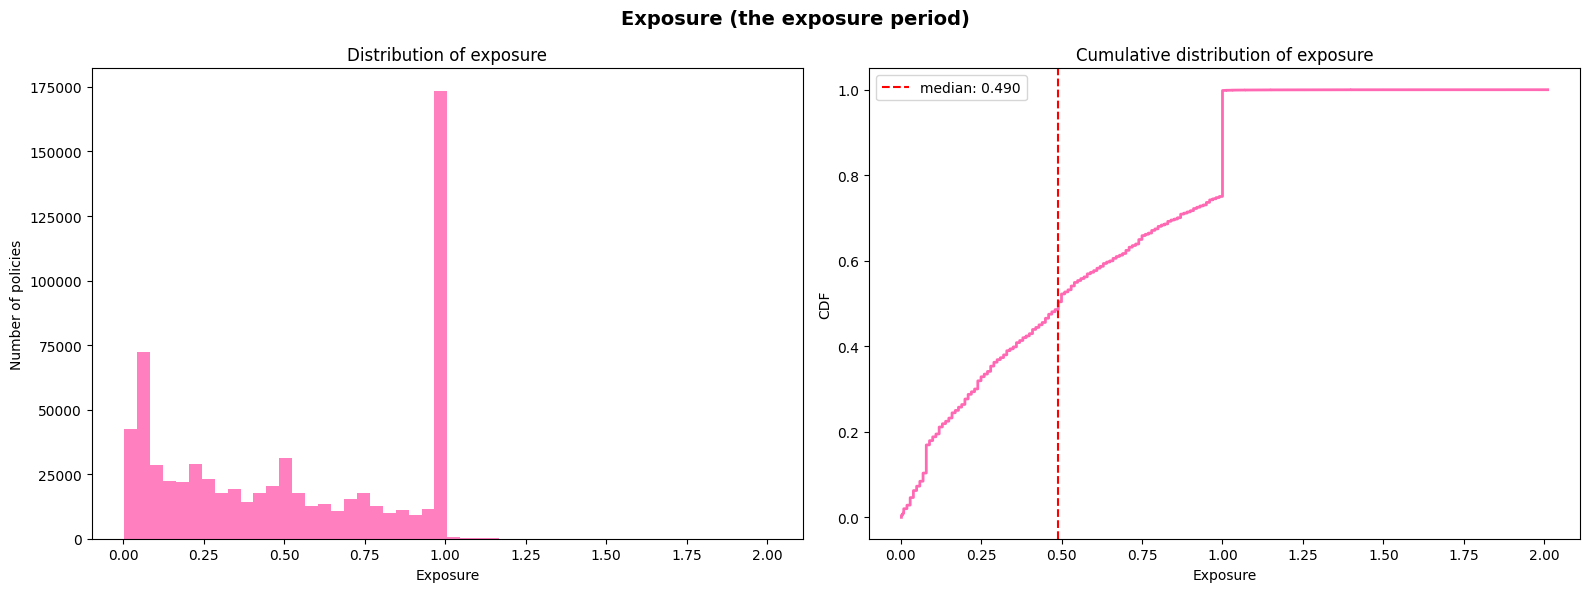

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Exposure (the exposure period)",
             fontsize=14, fontweight="bold")

#Distribution of exposure
axes[0].hist(df["Exposure"], bins=50, color='hotpink', alpha=0.85)
axes[0].set_xlabel("Exposure")
axes[0].set_ylabel("Number of policies")
axes[0].set_title("Distribution of exposure")

# Cumulative exposure
sorted_exp = np.sort(df["Exposure"].values)
cdf = np.arange(1, len(sorted_exp) + 1) / len(sorted_exp)
axes[1].plot(sorted_exp, cdf, color='hotpink', linewidth=2)
axes[1].set_xlabel("Exposure")
axes[1].set_ylabel("CDF")
axes[1].set_title("Cumulative distribution of exposure")
axes[1].axvline(df["Exposure"].median(), color='red', linestyle="--", linewidth=1.5,
                label=f"median: {df['Exposure'].median():.3f}")
axes[1].legend()

plt.tight_layout()

As we know from the data description, claim numbers were collected for 677,991 motor third-part liability policies (observed on a year). But there are some observations, where exposure exceeds one year:

In [15]:
print((df["Exposure"] > 1).sum())

1224


In [16]:
print((df["Exposure"] > 1).mean())

0.0018052751200935675


A small fraction of observations (0.18%) has exposure greater than one year. Since the analysis assumes annual policies, we will clip these observations to 1 to ensure consistency.

In [17]:
df["Exposure"] = df["Exposure"].clip(upper=1)

But we also have policies with excessively short terms. Such observations produce statistically unreliable annual frequency estimates: a single claim within a few days extrapolates to implausible annual rates (e.g., ClaimFreq = 100–732). We will exlude those from dataset.

In [18]:
print(f"Before: {df.shape[0]:,} policies")
print(f"Exposure < 0.01: {(df['Exposure'] < 0.01).sum():,}")

Before: 678,013 policies
Exposure < 0.01: 6,877


In [19]:
df = df[df["Exposure"] >= 0.01].reset_index(drop=True)

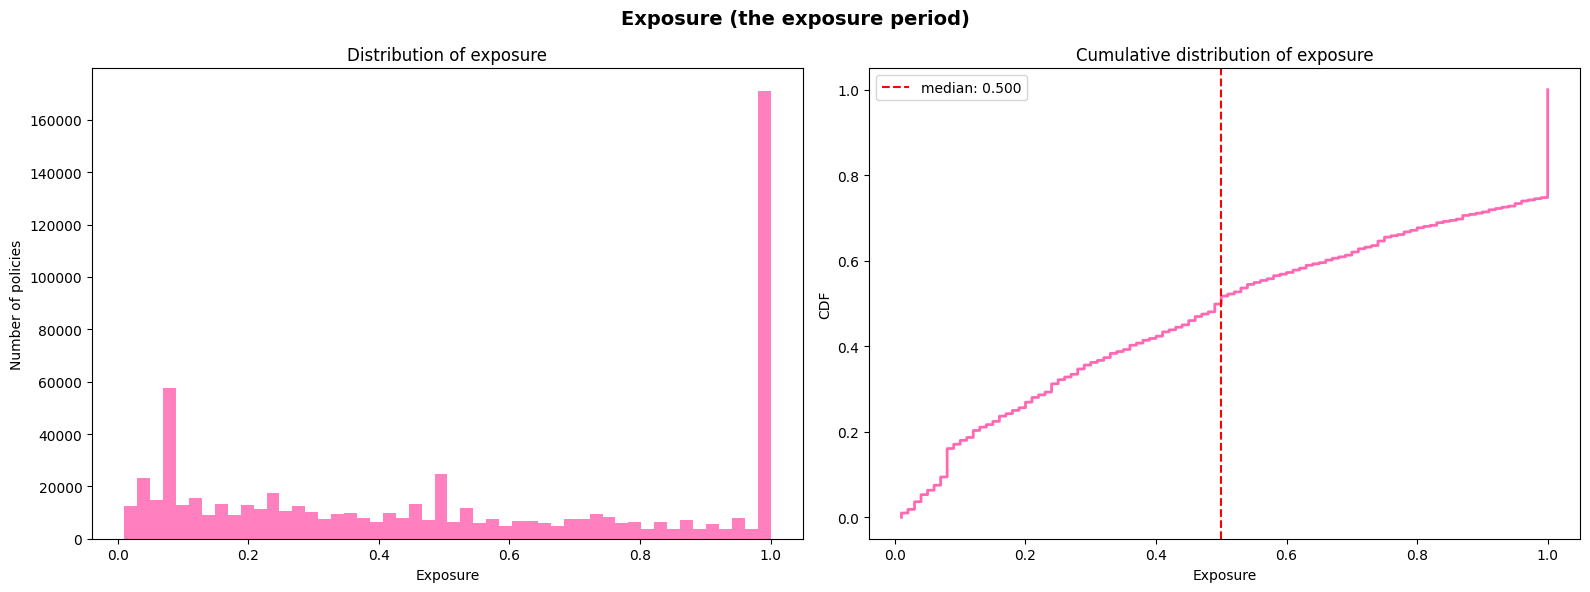

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Exposure (the exposure period)",
             fontsize=14, fontweight="bold")

#Distribution of exposure
axes[0].hist(df["Exposure"], bins=50, color='hotpink', alpha=0.85)
axes[0].set_xlabel("Exposure")
axes[0].set_ylabel("Number of policies")
axes[0].set_title("Distribution of exposure")

# Cumulative exposure
sorted_exp = np.sort(df["Exposure"].values)
cdf = np.arange(1, len(sorted_exp) + 1) / len(sorted_exp)
axes[1].plot(sorted_exp, cdf, color='hotpink', linewidth=2)
axes[1].set_xlabel("Exposure")
axes[1].set_ylabel("CDF")
axes[1].set_title("Cumulative distribution of exposure")
axes[1].axvline(df["Exposure"].median(), color='red', linestyle="--", linewidth=1.5,
                label=f"median: {df['Exposure'].median():.3f}")
axes[1].legend()

plt.tight_layout()

In [21]:
df["ClaimFreq"] = df["ClaimNb"] / df["Exposure"].clip(lower=1e-6)

## Numeric variables

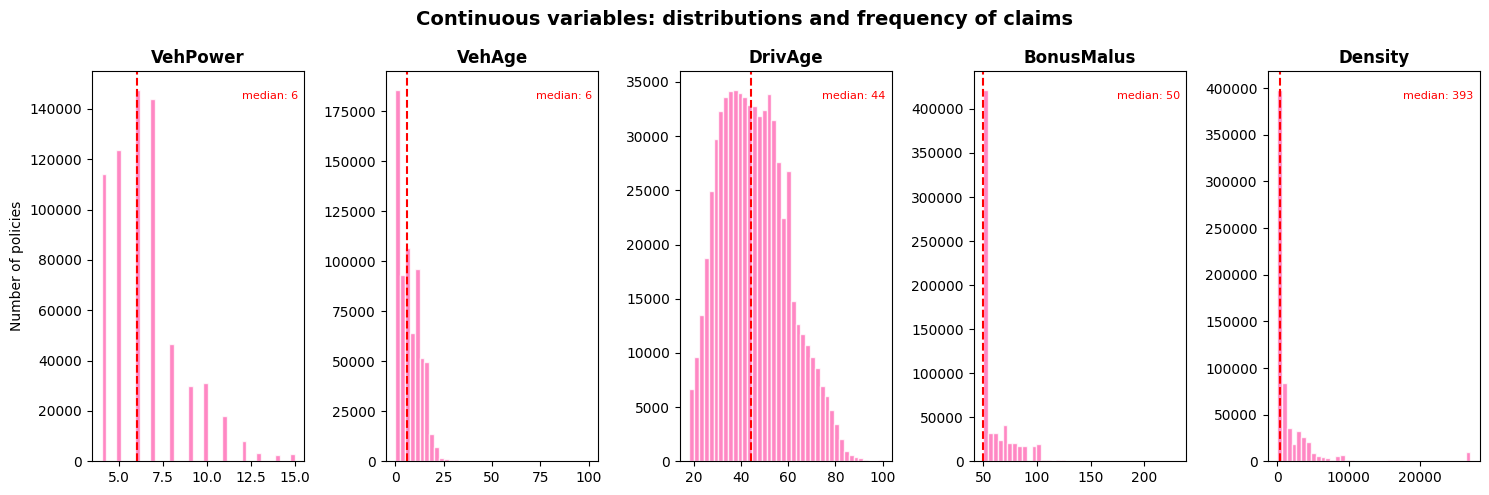

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
fig.suptitle('Continuous variables: distributions and frequency of claims',
             fontsize=14, fontweight="bold")

for i, col in enumerate(num_cols):
    ax_top = axes[i]

    # frequency distribution histogram
    ax_top.hist(df[col], bins=40, color='hotpink', alpha=0.8, edgecolor="white")
    ax_top.set_title(col, fontsize=12, fontweight="bold")
    ax_top.set_ylabel("Number of policies" if i == 0 else "")
    median_val = df[col].median()
    ax_top.axvline(median_val, color='red', linestyle="--", linewidth=1.5)
    ax_top.text(0.97, 0.95, f"median: {median_val:.0f}", transform=ax_top.transAxes,
                ha="right", va="top", fontsize=8, color='red')

plt.tight_layout()

Almost all variables exhibit right-skewed distribution.
Avarage insurance portfolio: cars with average engine power, cars approximately 6 years old and drivers approximately 40–50 years old.

There are long tails and outliers (especially in Density and BonusMalus).

Density requires log transformation

Other variables may need binning or categorization.

In [23]:
df["log_Density"] = np.log1p(df["Density"])

/tmp/ipykernel_1562/1215875473.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_grp,
/tmp/ipykernel_1562/1215875473.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_grp,
/tmp/ipykernel_1562/1215875473.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_grp,
/tmp/ipykernel_1562/1215875473.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_grp,
/tmp/ipykernel_1562/12158754

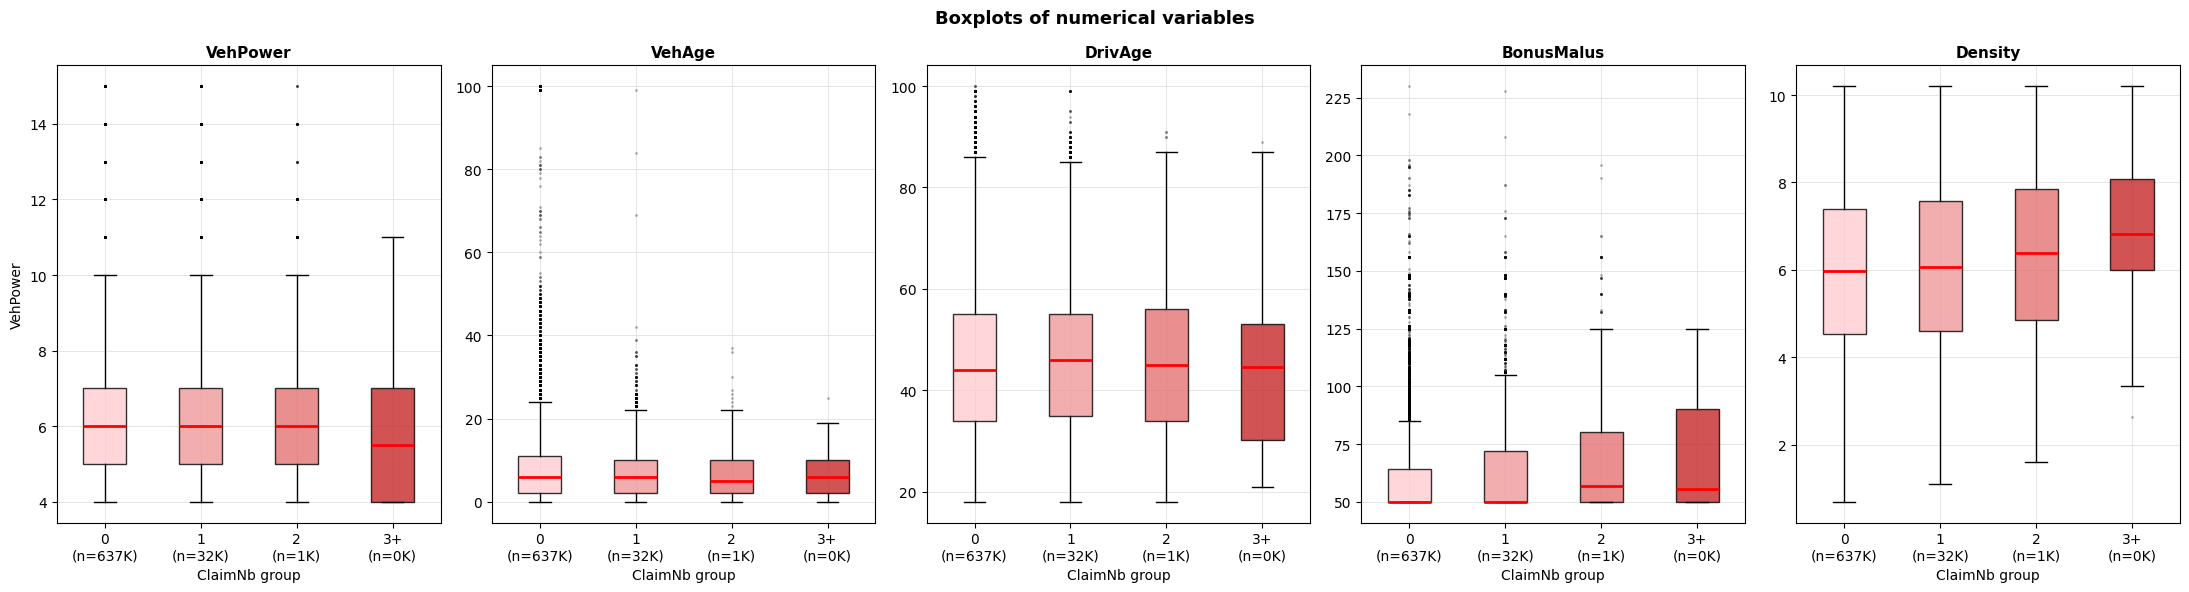

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle("Boxplots of numerical variables",
             fontsize=13, fontweight="bold")

#We're limiting ClaimNb to 3+ for clarity
df["claimnb_group"] = df["ClaimNb"].clip(upper=3).astype(str)
df["claimnb_group"] = df["claimnb_group"].replace("3", "3+")

for i, col in enumerate(num_cols):

    # log Density
    if col == "Density":
        plot_data = df["log_Density"]
        ylabel = "log(1 + Density)"
    else:
        plot_data = df[col]
        ylabel = col

    groups      = ["0", "1", "2", "3+"]
    data_by_grp = [plot_data[df["claimnb_group"] == g].values for g in groups]
    n_by_grp    = [df["claimnb_group"].value_counts().get(g, 0) for g in groups]

    bp = axes[i].boxplot(data_by_grp,
                         labels=[f"{g}\n(n={n//1000}K)" for g, n in zip(groups, n_by_grp)],
                         patch_artist=True,
                         medianprops=dict(color="red", linewidth=2),
                         flierprops=dict(marker=".", markersize=2,
                                         alpha=0.3, color="gray"))


    colors = ["#FFCDD2", "#EF9A9A", "#E57373", "#C62828"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    axes[i].set_title(col, fontweight="bold", fontsize=11)
    axes[i].set_xlabel("ClaimNb group")
    axes[i].set_ylabel(ylabel if i == 0 else "")
    axes[i].grid(True, color="#E0E0E0", linewidth=0.6)

plt.tight_layout()

In [25]:
df = df.drop(columns=['claimnb_group'])

Strong predictors: BonusMalus, Density

Moderate: DrivAge

Weak: VehPower, VehAge

### VehPower

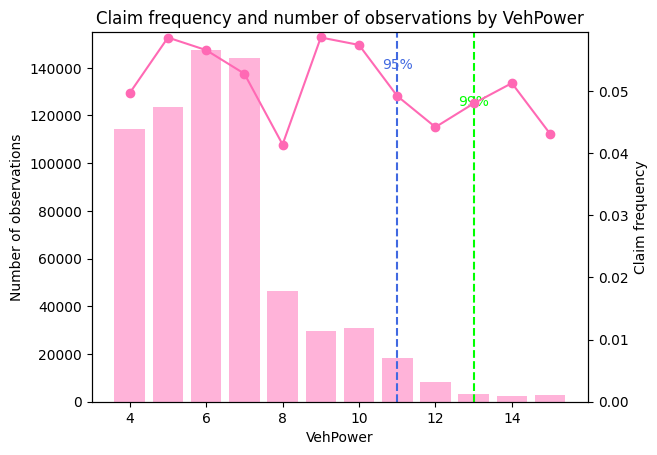

In [26]:
grouped = df.groupby("VehPower").agg(
    frequency=("ClaimNb", "mean"),
    count=("ClaimNb", "size")).reset_index().sort_values("VehPower")

grouped["cum_count"] = grouped["count"].cumsum()
grouped["cum_share"] = grouped["cum_count"] / grouped["count"].sum()

vp95 = grouped.loc[grouped["cum_share"] >= 0.95, "VehPower"].min()
vp99 = grouped.loc[grouped["cum_share"] >= 0.99, "VehPower"].min()

fig, ax1 = plt.subplots()
ax1.bar(grouped["VehPower"], grouped["count"], alpha=0.5, color="hotpink")
ax1.set_xlabel("VehPower")
ax1.set_ylabel("Number of observations")

ax2 = ax1.twinx()
ax2.plot(grouped["VehPower"], grouped["frequency"], marker='o', color="hotpink")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Claim frequency")

ax1.axvline(vp95, linestyle="--", color="royalblue")
ax1.axvline(vp99, linestyle="--", color="lime")

y_max = ax1.get_ylim()[1]

ax1.text(vp95, y_max * 0.9, "95%", color="royalblue", ha="center")
ax1.text(vp99, y_max * 0.8, "99%", color="lime", ha="center")

plt.title("Claim frequency and number of observations by VehPower")

plt.show()

We can see that observations become sparse beyond 99th percentile (VehPower = 13) and the frequency trend starts to exhibit increased volatility. We will clip data beyond this point.

In [27]:
df["VehPower"] = df["VehPower"].clip(upper=13)

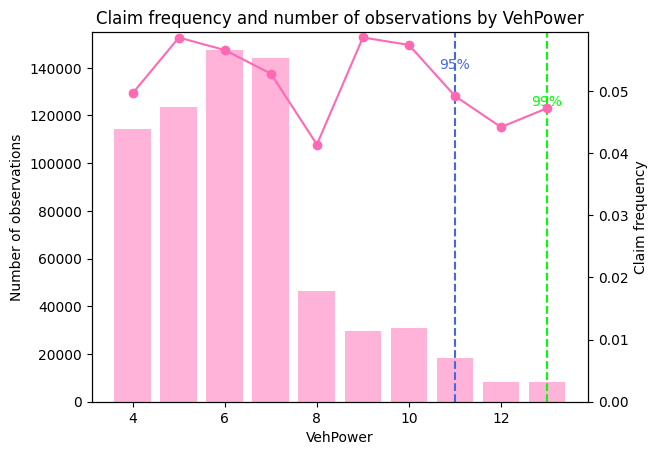

In [28]:
grouped = df.groupby("VehPower").agg(
    frequency=("ClaimNb", "mean"),
    count=("ClaimNb", "size")).reset_index().sort_values("VehPower")

grouped["cum_count"] = grouped["count"].cumsum()
grouped["cum_share"] = grouped["cum_count"] / grouped["count"].sum()

vp95 = grouped.loc[grouped["cum_share"] >= 0.95, "VehPower"].min()
vp99 = grouped.loc[grouped["cum_share"] >= 0.99, "VehPower"].min()

fig, ax1 = plt.subplots()
ax1.bar(grouped["VehPower"], grouped["count"], alpha=0.5, color="hotpink")
ax1.set_xlabel("VehPower")
ax1.set_ylabel("Number of observations")

ax2 = ax1.twinx()
ax2.plot(grouped["VehPower"], grouped["frequency"], marker='o', color="hotpink")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Claim frequency")

ax1.axvline(vp95, linestyle="--", color="royalblue")
ax1.axvline(vp99, linestyle="--", color="lime")

y_max = ax1.get_ylim()[1]

ax1.text(vp95, y_max * 0.9, "95%", color="royalblue", ha="center")
ax1.text(vp99, y_max * 0.8, "99%", color="lime", ha="center")

plt.title("Claim frequency and number of observations by VehPower")

plt.show()

### VehAge

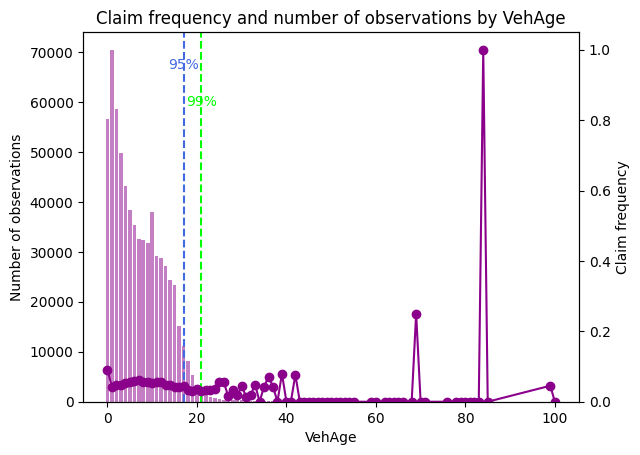

In [29]:
grouped = df.groupby("VehAge").agg(
    frequency=("ClaimNb", "mean"),
    count=("ClaimNb", "size")).reset_index().sort_values("VehAge")

grouped["cum_count"] = grouped["count"].cumsum()
grouped["cum_share"] = grouped["cum_count"] / grouped["count"].sum()

vp95 = grouped.loc[grouped["cum_share"] >= 0.95, "VehAge"].min()
vp99 = grouped.loc[grouped["cum_share"] >= 0.99, "VehAge"].min()

fig, ax1 = plt.subplots()
ax1.bar(grouped["VehAge"], grouped["count"], alpha=0.5, color="darkmagenta")
ax1.set_xlabel("VehAge")
ax1.set_ylabel("Number of observations")

ax2 = ax1.twinx()
ax2.plot(grouped["VehAge"], grouped["frequency"], marker='o', color="darkmagenta")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Claim frequency")

ax1.axvline(vp95, linestyle="--", color="royalblue")
ax1.axvline(vp99, linestyle="--", color="lime")

y_max = ax1.get_ylim()[1]

ax1.text(vp95, y_max * 0.9, "95%", color="royalblue", ha="center")
ax1.text(vp99, y_max * 0.8, "99%", color="lime", ha="center")

plt.title("Claim frequency and number of observations by VehAge")

plt.show()

 There is little data and it is highly volatile beyond the 99th percentile (around 20 years), however there are many VehAge options (vehicle ages can reach up to 100 years). We will clip  data at the 99th percentile.

In [30]:
df["VehAge"] = df["VehAge"].clip(upper=20)

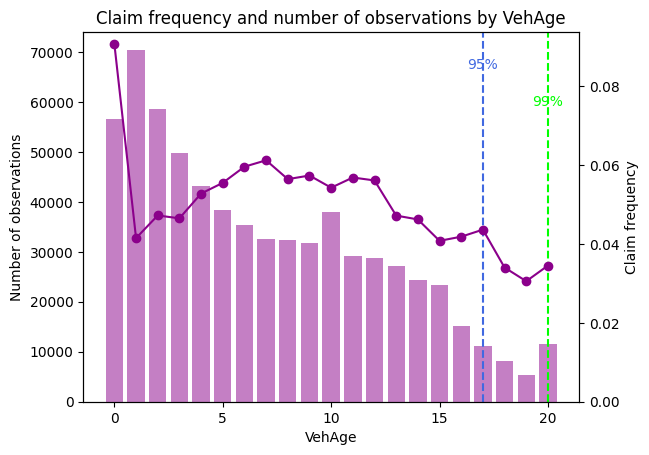

In [31]:
grouped = df.groupby("VehAge").agg(
    frequency=("ClaimNb", "mean"),
    count=("ClaimNb", "size")).reset_index().sort_values("VehAge")

grouped["cum_count"] = grouped["count"].cumsum()
grouped["cum_share"] = grouped["cum_count"] / grouped["count"].sum()

vp95 = grouped.loc[grouped["cum_share"] >= 0.95, "VehAge"].min()
vp99 = grouped.loc[grouped["cum_share"] >= 0.99, "VehAge"].min()

fig, ax1 = plt.subplots()
ax1.bar(grouped["VehAge"], grouped["count"], alpha=0.5, color="darkmagenta")
ax1.set_xlabel("VehAge")
ax1.set_ylabel("Number of observations")

ax2 = ax1.twinx()
ax2.plot(grouped["VehAge"], grouped["frequency"], marker='o', color="darkmagenta")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Claim frequency")

ax1.axvline(vp95, linestyle="--", color="royalblue")
ax1.axvline(vp99, linestyle="--", color="lime")

y_max = ax1.get_ylim()[1]

ax1.text(vp95, y_max * 0.9, "95%", color="royalblue", ha="center")
ax1.text(vp99, y_max * 0.8, "99%", color="lime", ha="center")

plt.title("Claim frequency and number of observations by VehAge")

plt.show()

### DrivAge

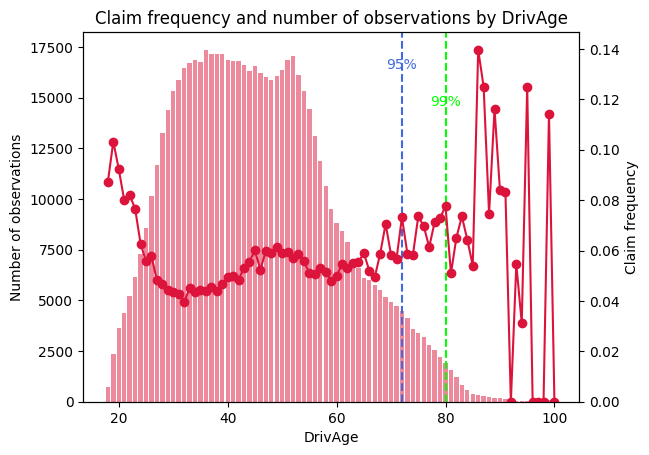

In [32]:
grouped = df.groupby("DrivAge").agg(
    frequency=("ClaimNb", "mean"),
    count=("ClaimNb", "size")).reset_index().sort_values("DrivAge")

grouped["cum_count"] = grouped["count"].cumsum()
grouped["cum_share"] = grouped["cum_count"] / grouped["count"].sum()

vp95 = grouped.loc[grouped["cum_share"] >= 0.95, "DrivAge"].min()
vp99 = grouped.loc[grouped["cum_share"] >= 0.99, "DrivAge"].min()

fig, ax1 = plt.subplots()
ax1.bar(grouped["DrivAge"], grouped["count"], alpha=0.5, color="crimson")
ax1.set_xlabel("DrivAge")
ax1.set_ylabel("Number of observations")

ax2 = ax1.twinx()
ax2.plot(grouped["DrivAge"], grouped["frequency"], marker='o', color="crimson")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Claim frequency")

ax1.axvline(vp95, linestyle="--", color="royalblue")
ax1.axvline(vp99, linestyle="--", color="lime")

y_max = ax1.get_ylim()[1]

ax1.text(vp95, y_max * 0.9, "95%", color="royalblue", ha="center")
ax1.text(vp99, y_max * 0.8, "99%", color="lime", ha="center")

plt.title("Claim frequency and number of observations by DrivAge")

plt.show()

The highest insurance risk is observed among young drivers, and the risk also begins to rise among drivers aged 60 and older. After age 80 (approximately the 99th percentile), the data becomes highly volatile. However, if we clip data at the 99th percentile (age 80), too many observations will end up in a single bin. We will clip data at age 90 to preserve the data distribution,

In [33]:
df["DrivAge"] = df["DrivAge"].clip(upper=90)

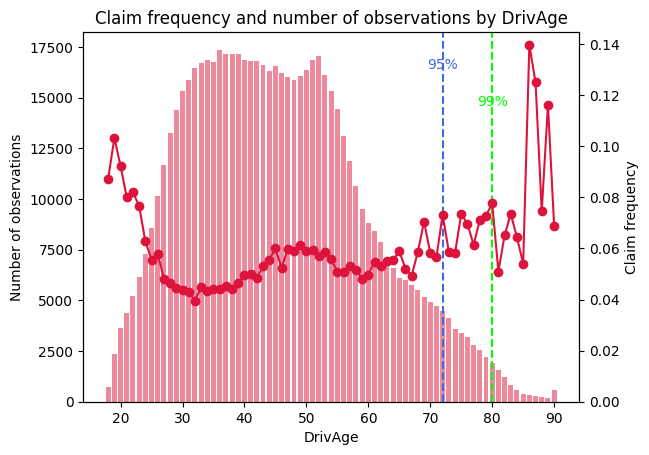

In [34]:
grouped = df.groupby("DrivAge").agg(
    frequency=("ClaimNb", "mean"),
    count=("ClaimNb", "size")).reset_index().sort_values("DrivAge")

grouped["cum_count"] = grouped["count"].cumsum()
grouped["cum_share"] = grouped["cum_count"] / grouped["count"].sum()

vp95 = grouped.loc[grouped["cum_share"] >= 0.95, "DrivAge"].min()
vp99 = grouped.loc[grouped["cum_share"] >= 0.99, "DrivAge"].min()

fig, ax1 = plt.subplots()
ax1.bar(grouped["DrivAge"], grouped["count"], alpha=0.5, color="crimson")
ax1.set_xlabel("DrivAge")
ax1.set_ylabel("Number of observations")

ax2 = ax1.twinx()
ax2.plot(grouped["DrivAge"], grouped["frequency"], marker='o', color="crimson")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Claim frequency")

ax1.axvline(vp95, linestyle="--", color="royalblue")
ax1.axvline(vp99, linestyle="--", color="lime")

y_max = ax1.get_ylim()[1]

ax1.text(vp95, y_max * 0.9, "95%", color="royalblue", ha="center")
ax1.text(vp99, y_max * 0.8, "99%", color="lime", ha="center")

plt.title("Claim frequency and number of observations by DrivAge")

plt.show()

### BonusMalus

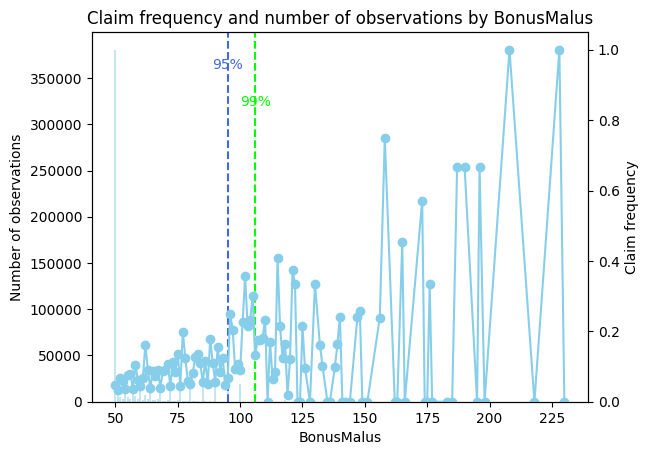

In [35]:
grouped = df.groupby("BonusMalus").agg(
    frequency=("ClaimNb", "mean"),
    count=("ClaimNb", "size")).reset_index().sort_values("BonusMalus")

grouped["cum_count"] = grouped["count"].cumsum()
grouped["cum_share"] = grouped["cum_count"] / grouped["count"].sum()

vp95 = grouped.loc[grouped["cum_share"] >= 0.95, "BonusMalus"].min()
vp99 = grouped.loc[grouped["cum_share"] >= 0.99, "BonusMalus"].min()

fig, ax1 = plt.subplots()
ax1.bar(grouped["BonusMalus"], grouped["count"], alpha=0.5, color="skyblue")
ax1.set_xlabel("BonusMalus")
ax1.set_ylabel("Number of observations")

ax2 = ax1.twinx()
ax2.plot(grouped["BonusMalus"], grouped["frequency"], marker='o', color="skyblue")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Claim frequency")

ax1.axvline(vp95, linestyle="--", color="royalblue")
ax1.axvline(vp99, linestyle="--", color="lime")

y_max = ax1.get_ylim()[1]

ax1.text(vp95, y_max * 0.9, "95%", color="royalblue", ha="center")
ax1.text(vp99, y_max * 0.8, "99%", color="lime", ha="center")

plt.title("Claim frequency and number of observations by BonusMalus")

plt.show()

The bonus-malus coefficient is an indicator of the accident rate of driving, which affects the cost of the policy. The coefficient can have the value of a "Bonus", which is a discount for accident-free driving (value is less than 100), or a "Bonus", which is a fine for emergency driving (value is more than 100). We can see that the plot turns out to be volatile after reaching the value of 150, so we are going to clip data at this value.

In [36]:
df["BonusMalus"] = df["BonusMalus"].clip(upper=150)

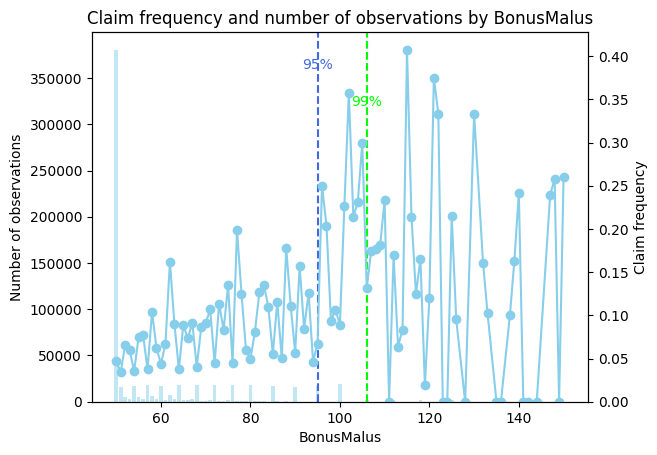

In [37]:
grouped = df.groupby("BonusMalus").agg(
    frequency=("ClaimNb", "mean"),
    count=("ClaimNb", "size")).reset_index().sort_values("BonusMalus")

grouped["cum_count"] = grouped["count"].cumsum()
grouped["cum_share"] = grouped["cum_count"] / grouped["count"].sum()

vp95 = grouped.loc[grouped["cum_share"] >= 0.95, "BonusMalus"].min()
vp99 = grouped.loc[grouped["cum_share"] >= 0.99, "BonusMalus"].min()

fig, ax1 = plt.subplots()
ax1.bar(grouped["BonusMalus"], grouped["count"], alpha=0.5, color="skyblue")
ax1.set_xlabel("BonusMalus")
ax1.set_ylabel("Number of observations")

ax2 = ax1.twinx()
ax2.plot(grouped["BonusMalus"], grouped["frequency"], marker='o', color="skyblue")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Claim frequency")

ax1.axvline(vp95, linestyle="--", color="royalblue")
ax1.axvline(vp99, linestyle="--", color="lime")

y_max = ax1.get_ylim()[1]

ax1.text(vp95, y_max * 0.9, "95%", color="royalblue", ha="center")
ax1.text(vp99, y_max * 0.8, "99%", color="lime", ha="center")

plt.title("Claim frequency and number of observations by BonusMalus")

plt.show()

### Density

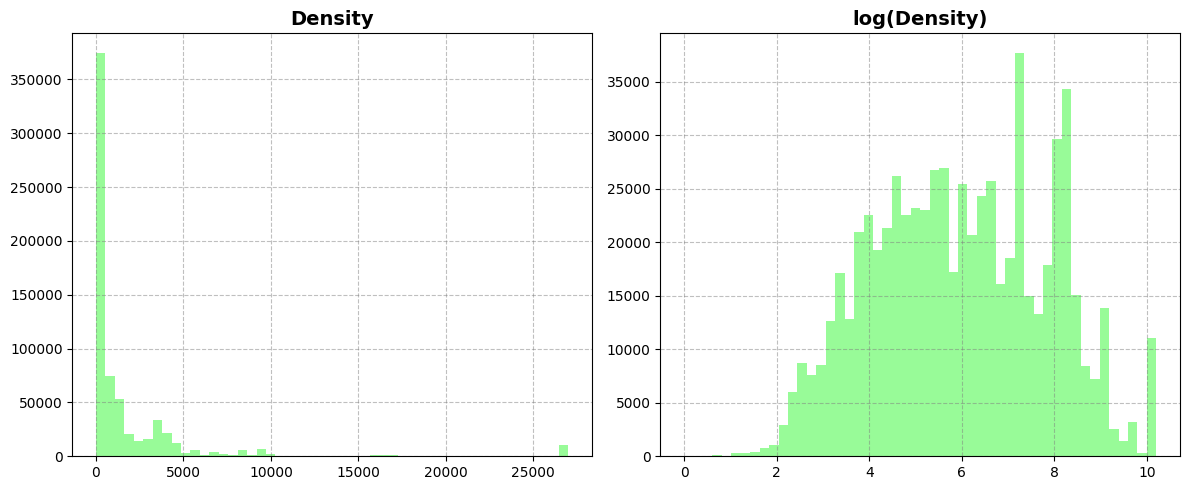

In [38]:
# Density
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['Density'],bins=50,color='palegreen')

plt.title('Density',fontsize=14,fontweight='bold')

plt.grid(color='gray', linestyle='--', alpha=0.5)

# Log Density
plt.subplot(1,2,2)
plt.hist(np.log(df['Density']),bins=50,color='palegreen')

plt.title('log(Density)',fontsize=14,fontweight='bold')

plt.grid(color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

As we saw earlier, Density has a strong asymmetry: there are many small values, while there is a large right tail and rare extreme values. After logarithmization, the distribution became more symmetrical and closer to normal.

We've did log Density before, so now we drop original column Density

In [39]:
df = df.drop(columns=['Density'])

### Correlation matrix of numeric variables

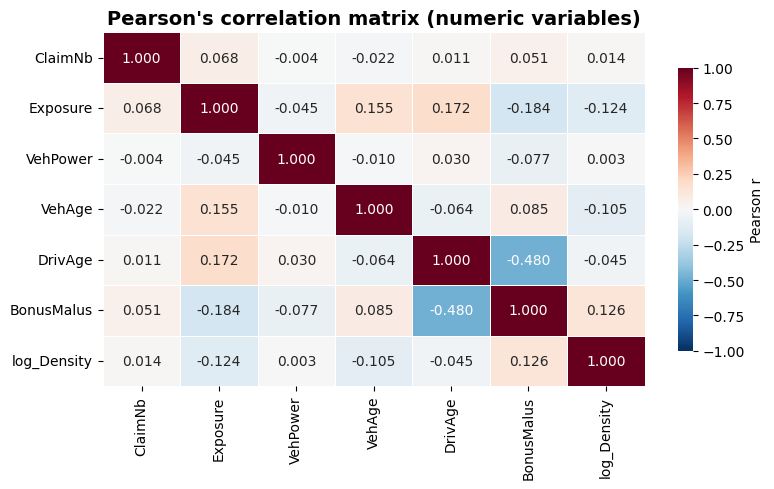

In [40]:
corr_cols = ['ClaimNb','Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'log_Density']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={"size": 10}, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"})

ax.set_title("Pearson's correlation matrix (numeric variables)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

The correlation matrix shows the absence of strong multicollinearity between numerical features. Most correlation coefficients have low modulus values, which makes the feature set suitable for building GLM and ML models. The most noticeable relationship is observed between the driver's age (DrivAge) and the bonus-malus coefficient (BonusMalus), which corresponds to the insurance logic.

In [41]:
df

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Region,ClaimFreq,log_Density
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,R82,10.000000,7.104965
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,R82,1.298701,7.104965
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,R22,1.333333,4.007333
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,R72,11.111111,4.343805
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,R72,1.190476,4.343805
...,...,...,...,...,...,...,...,...,...,...,...,...,...
671131,6114299.0,0,0.01,C,10,2,55,100,B12,Regular,R93,0.000000,5.159055
671132,6114300.0,0,0.01,E,5,3,23,100,B12,Regular,R26,0.000000,8.218518
671133,6114302.0,0,0.01,C,10,5,37,50,B12,Regular,R93,0.000000,5.181784
671134,6114303.0,0,0.01,F,11,0,64,50,B12,Diesel,R11,0.000000,10.028798


## Train/Test split

In [42]:
random_state = 2026
np.random.seed(random_state)

data = df.copy()
data["has_claim"] = (data["ClaimNb"] > 0).astype(int)

features = ['Area','VehPower','VehAge','DrivAge','BonusMalus','VehBrand','VehGas','Region','log_Density']

# 70 / 15 / 15
train_df, temp_df = train_test_split(data, test_size=0.30, random_state=random_state, stratify=data["has_claim"])
valid_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=random_state, stratify=temp_df["has_claim"])

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Features
X_train, X_valid, X_test = train_df[features], valid_df[features], test_df[features]

# GLM / ZINB: target = ClaimNb, offset = log(Exposure)
y_train_glm, y_valid_glm, y_test_glm = train_df["ClaimNb"], valid_df["ClaimNb"], test_df["ClaimNb"]
offset_train, offset_valid, offset_test = np.log(train_df["Exposure"]), np.log(valid_df["Exposure"]), np.log(test_df["Exposure"])

# ML (XGBoost, RF, steck): target = ClaimFreq, weights = Exposure
y_train_ml, y_valid_ml, y_test_ml = train_df["ClaimFreq"], valid_df["ClaimFreq"], test_df["ClaimFreq"]
w_train, w_valid, w_test = train_df["Exposure"], valid_df["Exposure"], test_df["Exposure"]

train_df = train_df.drop(columns=["has_claim"])

## Categorical variables/data transformation

In [43]:
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique categories")

Area: 6 unique categories
VehBrand: 11 unique categories
VehGas: 2 unique categories
Region: 22 unique categories


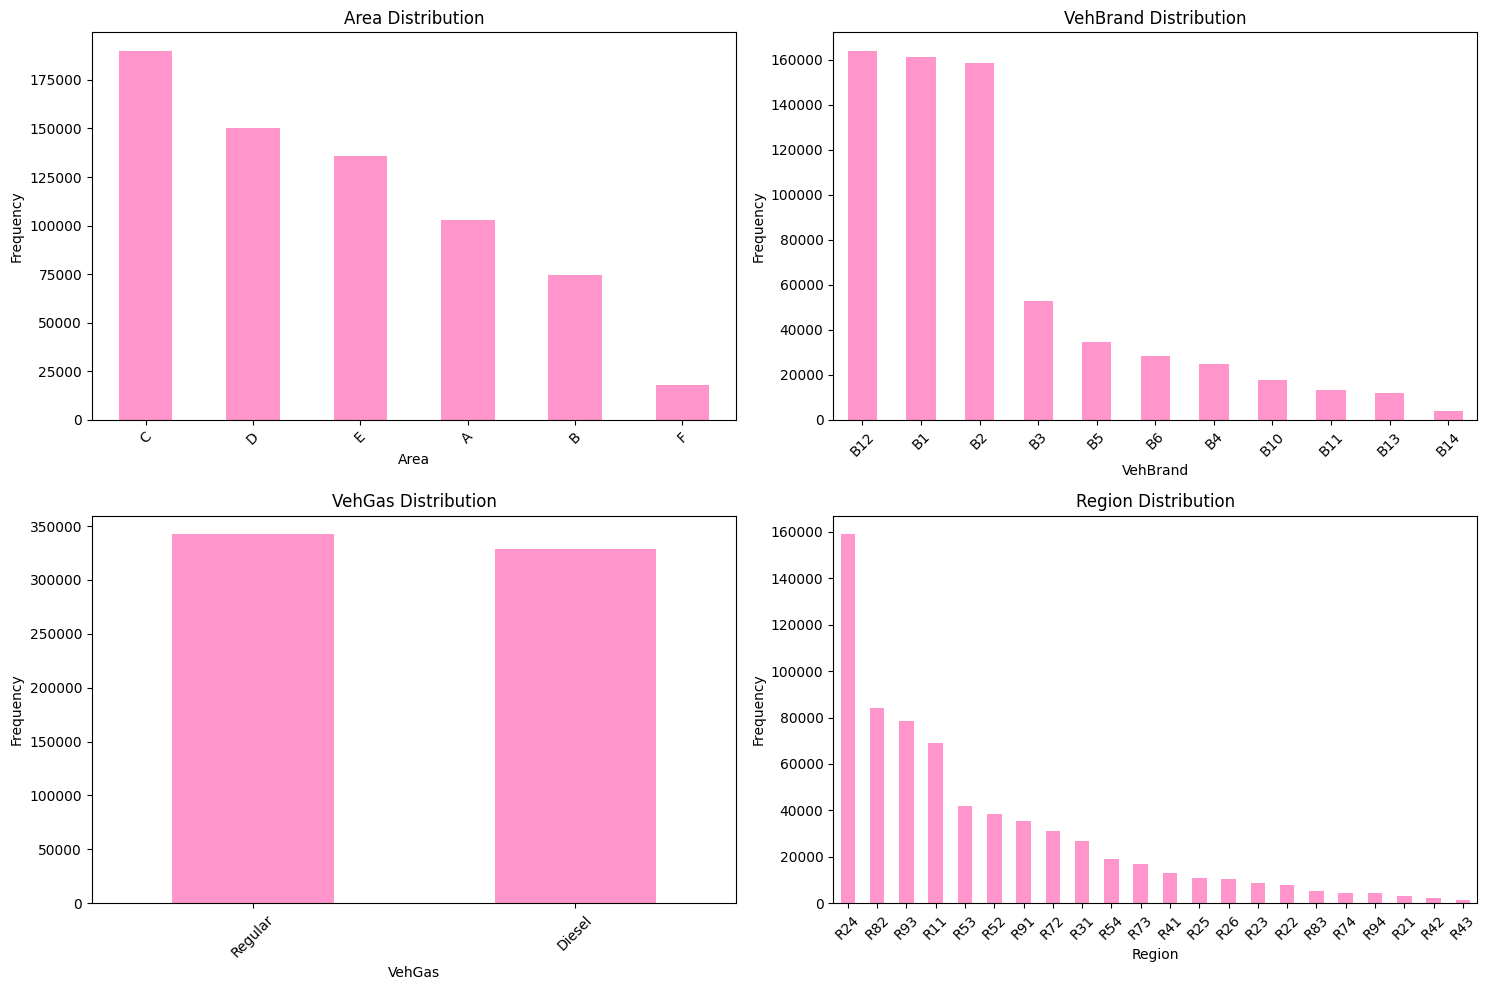

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(
        kind="bar",
        ax=axes[i],
        color ='hotpink',
        alpha = 0.7)
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_ylabel("Frequency")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Area, VehGas and VehBrand have a small cardinality, which is good for one-hot encoding

In [45]:
cat_cols_ohe = ["Area", "VehGas", "VehBrand"]
num_cols = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Region", "log_Density"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore", dtype=int)
ohe.fit(X_train[cat_cols_ohe])

def apply_ohe(df, ohe, cat_cols_ohe, num_cols):
    ohe_array = ohe.transform(df[cat_cols_ohe])
    ohe_cols = ohe.get_feature_names_out(cat_cols_ohe)
    ohe_df = pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
    return pd.concat([df[num_cols], ohe_df], axis=1)

X_train = apply_ohe(X_train, ohe, cat_cols_ohe, num_cols)
X_valid = apply_ohe(X_valid, ohe, cat_cols_ohe, num_cols)
X_test  = apply_ohe(X_test,  ohe, cat_cols_ohe, num_cols)

Region has 22 unique categories with widely varying numbers of observations: from 966 (R43) to 112,000 (R24). Small regions yield unstable coefficient estimates in the GLM, so instead of using 21 dummy variables, we group the regions by observed claim frequency.
The thresholds were selected empirically:
Groups 1_low < 0.088 Freq, 2_med_low 0.088–0.097 Freq, 3_medium 0.097–0.107 Freq, 4_med_high 0.107–0.120 Freq, 5_high > 0.120 Freq
Mapping is built only on the train set, then applied to the valid and test sets to avoid data leakage. Result = 4 dummy columns after drop="first" instead of 21, while the substantive variation in risk across regions is preserved.

In [46]:
region_stats = train_df.groupby("Region").agg(
    exposure=("Exposure", "sum"),
    claims=("ClaimNb", "sum")
).assign(freq=lambda x: x["claims"] / x["exposure"])

# fit train
def assign_risk_group(freq):
    if freq < 0.088:
        return "1_low"
    elif freq < 0.097:
        return "2_med_low"
    elif freq < 0.107:
        return "3_medium"
    elif freq < 0.120:
        return "4_med_high"
    else:
        return "5_high"

region_to_group = region_stats["freq"].apply(assign_risk_group).to_dict()
print("Mapping of regions:\n", pd.Series(region_to_group).sort_values())

for X in [X_train, X_valid, X_test]:
    X["Region_risk"] = X["Region"].map(region_to_group).fillna("3_medium")

# ohe Region_risk
ohe_region = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore", dtype=np.int32)
ohe_region.fit(X_train[["Region_risk"]])

def apply_ohe_region(df, ohe_region):
    ohe_array = ohe_region.transform(df[["Region_risk"]])
    ohe_cols = ohe_region.get_feature_names_out(["Region_risk"])
    ohe_df = pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
    return pd.concat([df.drop(columns=["Region", "Region_risk"]), ohe_df], axis=1)

X_train = apply_ohe_region(X_train, ohe_region)
X_valid = apply_ohe_region(X_valid, ohe_region)
X_test  = apply_ohe_region(X_test,  ohe_region)

Mapping of regions:
 R83         1_low
R41         1_low
R73     2_med_low
R72     2_med_low
R23     2_med_low
R24     2_med_low
R25     2_med_low
R54     2_med_low
R53     2_med_low
R52     2_med_low
R43      3_medium
R31      3_medium
R26      3_medium
R91      3_medium
R82    4_med_high
R22    4_med_high
R74    4_med_high
R93    4_med_high
R42    4_med_high
R11        5_high
R21        5_high
R94        5_high
dtype: object


In [47]:
# Final check
print("Shapes:")
print(f"  X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}")

print("\nColumns:")
print(X_train.columns.tolist())

print("\nDtypes:")
print(X_train.dtypes)

print("\nNaN check:")
print(f"  X_train: {X_train.isnull().sum().sum()}")
print(f"  X_valid: {X_valid.isnull().sum().sum()}")
print(f"  X_test:  {X_test.isnull().sum().sum()}")

print("\nTargets and offsets:")
print(f"  y_train_glm:  min={y_train_glm.min()}, max={y_train_glm.max()}")
print(f"  y_train_ml:   min={y_train_ml.min():.4f}, max={y_train_ml.max():.4f}")
print(f"  offset_train: min={offset_train.min():.4f}, max={offset_train.max():.4f}")
print(f"  w_train:      min={w_train.min():.4f}, max={w_train.max():.4f}")

print("\nClass balance:")
print(f"  Train zero rate: {(y_train_glm == 0).mean():.4f}")
print(f"  Valid zero rate: {(y_valid_glm == 0).mean():.4f}")
print(f"  Test zero rate:  {(y_test_glm == 0).mean():.4f}")

Shapes:
  X_train: (469795, 25), X_valid: (100670, 25), X_test: (100671, 25)

Columns:
['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'log_Density', 'Area_B', 'Area_C', 'Area_D', 'Area_E', 'Area_F', 'VehGas_Regular', 'VehBrand_B10', 'VehBrand_B11', 'VehBrand_B12', 'VehBrand_B13', 'VehBrand_B14', 'VehBrand_B2', 'VehBrand_B3', 'VehBrand_B4', 'VehBrand_B5', 'VehBrand_B6', 'Region_risk_2_med_low', 'Region_risk_3_medium', 'Region_risk_4_med_high', 'Region_risk_5_high']

Dtypes:
VehPower                    int64
VehAge                      int64
DrivAge                     int64
BonusMalus                  int64
log_Density               float64
Area_B                      int64
Area_C                      int64
Area_D                      int64
Area_E                      int64
Area_F                      int64
VehGas_Regular              int64
VehBrand_B10                int64
VehBrand_B11                int64
VehBrand_B12                int64
VehBrand_B13                int64
VehBrand_B1

# Models building

## Quality metrics

In [48]:
def poisson_deviance(y_true, y_pred, weights=None):

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-10, None)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(y_true > 0, y_true / y_pred, 1.0)
        term1 = y_true * np.log(ratio)
    term2 = y_true - y_pred
    dev = 2 * (term1 - term2)

    if weights is None:
        return dev.mean()
    weights = np.asarray(weights, dtype=float)
    return np.sum(dev * weights) / np.sum(weights)


def gini_coefficient(y_true, y_pred, weights=None):

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.ones_like(y_true) if weights is None else np.asarray(weights, dtype=float)

    order = np.argsort(-y_pred)
    y_true_s = y_true[order]
    w_s = weights[order]

    cum_w = np.cumsum(w_s)
    cum_y = np.cumsum(y_true_s * w_s)

    total_w = cum_w[-1]
    total_y = cum_y[-1]
    if total_y == 0:
        return 0.0

    lorenz_x = cum_w / total_w
    lorenz_y = cum_y / total_y
    auc = np.trapezoid(lorenz_y, lorenz_x)

    return 2 * auc - 1


def evaluate_model(y_true, y_pred, weights=None, model_name="Model", split_name="Test"):
    return {
        "model": model_name,
        "split": split_name,
        "poisson_deviance": poisson_deviance(y_true, y_pred, weights),
        "mae": mean_absolute_error(y_true, y_pred, sample_weight=weights),
        "gini": gini_coefficient(y_true, y_pred, weights)}

In [49]:
all_results = []

## Baseline models

### Poisson GLM

In [50]:
# intercept
X_train_const = sm.add_constant(X_train, has_constant="add")
X_valid_const = sm.add_constant(X_valid, has_constant="add")
X_test_const = sm.add_constant(X_test, has_constant="add")

# fit Poisson GLM
poisson_glm = sm.GLM(
    endog=y_train_glm,
    exog=X_train_const,
    family=sm.families.Poisson(),
    offset=offset_train).fit()

print(poisson_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               469795
Model:                            GLM   Df Residuals:                   469769
Model Family:                 Poisson   Df Model:                           25
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -99322.
Date:                Mon, 11 May 2026   Deviance:                   1.5035e+05
Time:                        13:06:00   Pearson chi2:                 1.04e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01028
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -4

In [51]:
# аorecasts (on the ClaimNb scale)
y_pred_train = poisson_glm.predict(X_train_const, offset=offset_train)
y_pred_valid = poisson_glm.predict(X_valid_const, offset=offset_valid)
y_pred_test = poisson_glm.predict(X_test_const, offset=offset_test)

# metrics
results = []
results.append(evaluate_model(y_train_glm, y_pred_train, model_name="Poisson GLM", split_name="Train"))
results.append(evaluate_model(y_valid_glm, y_pred_valid, model_name="Poisson GLM", split_name="Valid"))
results.append(evaluate_model(y_test_glm, y_pred_test, model_name="Poisson GLM", split_name="Test"))

results_df = pd.DataFrame(results)
all_results.extend(results)
print(results_df.to_string(index=False))

#information criteria
print(f"Log-Likelihood: {poisson_glm.llf:.1f}")
print(f"AIC: {poisson_glm.aic:.1f}")

      model split  poisson_deviance      mae     gini
Poisson GLM Train          0.320033 0.099367 0.253570
Poisson GLM Valid          0.323483 0.099670 0.239803
Poisson GLM  Test          0.321622 0.099200 0.252832
Log-Likelihood: -99322.2
AIC: 198696.5


### ZIP GLM

In [52]:
zip_model = ZeroInflatedPoisson(
    endog=y_train_glm,
    exog=X_train_const,
    exog_infl=X_train_const,
    offset=offset_train.values,
    inflation="logit")

zip_result = zip_model.fit(
    method="bfgs",
    maxiter=200,
    disp=True,
    start_params=np.concatenate([
        np.zeros(X_train_const.shape[1]),
        poisson_glm.params.values]))

print(zip_result.summary())

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)


         Current function value: 0.210301
         Iterations: 200
         Function evaluations: 206
         Gradient evaluations: 206


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                 ClaimNb   No. Observations:               469795
Model:             ZeroInflatedPoisson   Df Residuals:                   469769
Method:                            MLE   Df Model:                           25
Date:                 Mon, 11 May 2026   Pseudo R-squ.:                 0.02562
Time:                         13:09:20   Log-Likelihood:                -98798.
converged:                       False   LL-Null:                   -1.0140e+05
Covariance Type:             nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
inflate_const                     -0.6908      0.208     -3.319      0.001      -1.099      -0.283
inflate_VehPower                  -0.1115      0.008    -13.973

In [53]:
# predictions (ClaimNb scale)
y_pred_train_zip = zip_result.predict(X_train_const, exog_infl=X_train_const, offset=offset_train.values)
y_pred_valid_zip = zip_result.predict(X_valid_const, exog_infl=X_valid_const, offset=offset_valid.values)
y_pred_test_zip = zip_result.predict(X_test_const, exog_infl=X_test_const, offset=offset_test.values)

# metrics
results = []
results.append(evaluate_model(y_train_glm, y_pred_train_zip, model_name="ZIP", split_name="Train"))
results.append(evaluate_model(y_valid_glm, y_pred_valid_zip, model_name="ZIP", split_name="Valid"))
results.append(evaluate_model(y_test_glm, y_pred_test_zip, model_name="ZIP", split_name="Test"))

results_df = pd.DataFrame(results)
all_results.extend(results)
print(results_df.to_string(index=False))

# information criteria
print(f"\nLog-Likelihood: {zip_result.llf:.1f}")
print(f"AIC: {zip_result.aic:.1f}")
print(f"(Comparison with Poisson GLM AIC: {poisson_glm.aic:.1f}")

model split  poisson_deviance      mae     gini
  ZIP Train          0.319048 0.099994 0.260125
  ZIP Valid          0.322655 0.100330 0.244520
  ZIP  Test          0.320260 0.099807 0.260928

Log-Likelihood: -98798.2
AIC: 197700.4
(Comparison with Poisson GLM AIC: 198696.5


### NB GLM

In [54]:
# fit NB GLM (NB2 parametrization)
nb_model = NegativeBinomial(
    endog=y_train_glm,
    exog=X_train_const,
    offset=offset_train.values,
    loglike_method="nb2")

nb_result = nb_model.fit(
    method="bfgs",
    maxiter=200,
    disp=True,
    start_params=np.concatenate([
        poisson_glm.params.values,
        [1.0]]))

print(nb_result.summary())
print(f"\nEstimated dispersion α: {nb_result.params['alpha']:.4f}")

Optimization terminated successfully.
         Current function value: 0.210848
         Iterations: 52
         Function evaluations: 55
         Gradient evaluations: 55
                     NegativeBinomial Regression Results                      
Dep. Variable:                ClaimNb   No. Observations:               469795
Model:               NegativeBinomial   Df Residuals:                   469769
Method:                           MLE   Df Model:                           25
Date:                Mon, 11 May 2026   Pseudo R-squ.:                 0.02236
Time:                        13:09:43   Log-Likelihood:                -99055.
converged:                       True   LL-Null:                   -1.0132e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const         

In [55]:
# predictions (ClaimNb scale)
y_pred_train_nb = nb_result.predict(X_train_const, offset=offset_train.values)
y_pred_valid_nb = nb_result.predict(X_valid_const, offset=offset_valid.values)
y_pred_test_nb = nb_result.predict(X_test_const, offset=offset_test.values)

# metrics
results = []
results.append(evaluate_model(y_train_glm, y_pred_train_nb, model_name="NB GLM", split_name="Train"))
results.append(evaluate_model(y_valid_glm, y_pred_valid_nb, model_name="NB GLM", split_name="Valid"))
results.append(evaluate_model(y_test_glm, y_pred_test_nb, model_name="NB GLM", split_name="Test"))

results_df = pd.DataFrame(results)
all_results.extend(results)
print(results_df.to_string(index=False))

# models comparison
print(f"\nLog-Likelihood: {nb_result.llf:.1f}")
print(f"AIC: {nb_result.aic:.1f}")
print(f"Poisson AIC: {poisson_glm.aic:.1f}")
print(f"ZIP AIC: {zip_result.aic:.1f}")

 model split  poisson_deviance      mae     gini
NB GLM Train          0.320045 0.099863 0.253559
NB GLM Valid          0.323489 0.100167 0.239704
NB GLM  Test          0.321623 0.099693 0.252831

Log-Likelihood: -99055.2
AIC: 198164.5
Poisson AIC: 198696.5
ZIP AIC: 197700.4


### ZINB GLM

In [86]:
n_features = X_train_const.shape[1]
zip_count_params = zip_result.params.values[n_features:]

# fit ZINB (BFGS, maxiter=1000)
zinb_model = ZeroInflatedNegativeBinomialP(
    endog=y_train_glm,
    exog=X_train_const,
    exog_infl=X_train_const,
    offset=offset_train.values,
    inflation="logit",
    p=2)

zinb_result = zinb_model.fit(
    method="bfgs",
    maxiter=1000,
    disp=True,
    start_params=np.concatenate([
        np.zeros(n_features),
        zip_count_params,
        [0.91]]),
    tol=1e-6)

print(zinb_result.summary())

Optimization terminated successfully.
         Current function value: 0.210458
         Iterations: 391
         Function evaluations: 397
         Gradient evaluations: 397
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                           ClaimNb   No. Observations:               469795
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                   469769
Method:                                      MLE   Df Model:                           25
Date:                           Mon, 11 May 2026   Pseudo R-squ.:                 0.02416
Time:                                   14:51:57   Log-Likelihood:                -98872.
converged:                                  True   LL-Null:                   -1.0132e+05
Covariance Type:                       nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
------

In [87]:
# predictions (ClaimNb scale)
y_pred_train_zinb = zinb_result.predict(X_train_const, exog_infl=X_train_const, offset=offset_train.values)
y_pred_valid_zinb = zinb_result.predict(X_valid_const, exog_infl=X_valid_const, offset=offset_valid.values)
y_pred_test_zinb = zinb_result.predict(X_test_const, exog_infl=X_test_const, offset=offset_test.values)

# metrics
results = []
results.append(evaluate_model(y_train_glm, y_pred_train_zinb, model_name="ZINB", split_name="Train"))
results.append(evaluate_model(y_valid_glm, y_pred_valid_zinb, model_name="ZINB", split_name="Valid"))
results.append(evaluate_model(y_test_glm, y_pred_test_zinb, model_name="ZINB", split_name="Test"))

results_df = pd.DataFrame(results)
all_results.extend(results)
print(results_df.to_string(index=False))

# final GLM comparison
print(f"\nLog-Likelihood: {zinb_result.llf:.1f}")
print(f"Alpha: {zinb_result.params['alpha']:.4f}")
print(f"Converged: {zinb_result.mle_retvals.get('converged', 'unknown')}")
print(f"\nAIC comparison:")
print(f"Poisson AIC: {poisson_glm.aic:.1f}")
print(f"NB AIC: {nb_result.aic:.1f}")
print(f"ZIP AIC: {zip_result.aic:.1f}")
print(f"ZINB AIC: {zinb_result.aic:.1f}")

model split  poisson_deviance      mae     gini
 ZINB Train          0.319119 0.099759 0.261367
 ZINB Valid          0.322556 0.100066 0.247486
 ZINB  Test          0.320741 0.099578 0.261074

Log-Likelihood: -98872.1
Alpha: 0.7473
Converged: True

AIC comparison:
Poisson AIC: 198696.5
NB AIC: 198164.5
ZIP AIC: 197700.4
ZINB AIC: 197850.2


### XGBoost

In [56]:
random_state = 2026

# XGBoost with ClaimFreq, Exposure = weights
dtrain = xgb.DMatrix(X_train, label=y_train_ml, weight=w_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid_ml, weight=w_valid)
dtest = xgb.DMatrix(X_test, label=y_test_ml, weight=w_test)

# standard parameters, no tuning
params = {
    "objective": "count:poisson",
    "eval_metric": "poisson-nloglik",
    "learning_rate": 0.05,
    "max_depth": 5,
    "min_child_weight": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "seed": random_state,
    "verbosity": 1,
    "nthread": -1}

# training
xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dvalid, "valid")],
    early_stopping_rounds=50,
    verbose_eval=50,)

print(f"\nBest iteration: {xgb_model.best_iteration}")
print(f"Best valid Poisson-nloglik: {xgb_model.best_score:.6f}")

[0]	train-poisson-nloglik:0.37844	valid-poisson-nloglik:0.38098
[50]	train-poisson-nloglik:0.35909	valid-poisson-nloglik:0.36230
[100]	train-poisson-nloglik:0.35486	valid-poisson-nloglik:0.35863
[150]	train-poisson-nloglik:0.35335	valid-poisson-nloglik:0.35759
[200]	train-poisson-nloglik:0.35249	valid-poisson-nloglik:0.35720
[250]	train-poisson-nloglik:0.35184	valid-poisson-nloglik:0.35695
[300]	train-poisson-nloglik:0.35126	valid-poisson-nloglik:0.35675
[350]	train-poisson-nloglik:0.35080	valid-poisson-nloglik:0.35665
[400]	train-poisson-nloglik:0.35031	valid-poisson-nloglik:0.35650
[450]	train-poisson-nloglik:0.34986	valid-poisson-nloglik:0.35640
[500]	train-poisson-nloglik:0.34945	valid-poisson-nloglik:0.35630
[550]	train-poisson-nloglik:0.34902	valid-poisson-nloglik:0.35622
[600]	train-poisson-nloglik:0.34866	valid-poisson-nloglik:0.35616
[650]	train-poisson-nloglik:0.34830	valid-poisson-nloglik:0.35610
[700]	train-poisson-nloglik:0.34795	valid-poisson-nloglik:0.35606
[750]	train-p

In [91]:
# predictions (XGBoost with ClaimFreq, so we turn in into ClaimNb)
y_pred_train_freq = xgb_model.predict(dtrain, iteration_range=(0, xgb_model.best_iteration + 1))
y_pred_valid_freq = xgb_model.predict(dvalid, iteration_range=(0, xgb_model.best_iteration + 1))
y_pred_test_freq = xgb_model.predict(dtest, iteration_range=(0, xgb_model.best_iteration + 1))

# transformation to the ClaimNb scale (as in GLM) for comparable metrics
y_pred_train_xgb = y_pred_train_freq * w_train.values
y_pred_valid_xgb = y_pred_valid_freq * w_valid.values
y_pred_test_xgb = y_pred_test_freq * w_test.values

# metrics (ClaimNB scale)
results = []
results.append(evaluate_model(y_train_glm, y_pred_train_xgb, model_name="XGBoost", split_name="Train"))
results.append(evaluate_model(y_valid_glm, y_pred_valid_xgb, model_name="XGBoost", split_name="Valid"))
results.append(evaluate_model(y_test_glm, y_pred_test_xgb, model_name="XGBoost", split_name="Test"))

results_df = pd.DataFrame(results)
all_results.extend(results)
print(results_df.to_string(index=False))

# comparison with GLMs
print(f"\nTest Gini comparison:")
print(f"Poisson: 0.2528")
print(f"NB: 0.2528")
print(f"ZIP: 0.2609")
print(f"ZINB: 0.2611")
print(f"XGBoost: {results[2]['gini']:.4f}")

  model split  poisson_deviance      mae     gini
XGBoost Train          0.294971 0.096075 0.394345
XGBoost Valid          0.306746 0.097252 0.339455
XGBoost  Test          0.303161 0.096596 0.359623

Test Gini comparison:
Poisson: 0.2528
NB: 0.2528
ZIP: 0.2609
ZINB: 0.2611
XGBoost: 0.3596


Now we will tune parameters

In [58]:
random_state = 2026

# DMatrix
dtrain_opt = xgb.DMatrix(X_train, label=y_train_ml, weight=w_train)
dvalid_opt = xgb.DMatrix(X_valid, label=y_valid_ml, weight=w_valid)

def objective(trial):
    params = {
        "objective": "count:poisson",
        "eval_metric": "poisson-nloglik",
        "seed": random_state,
        "verbosity": 0,
        # GPU settings
        "tree_method": "hist",
        "device": "cuda",
        # Hyperparameters to tune
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-3, 5.0, log=True)}

    model = xgb.train(
        params=params,
        dtrain=dtrain_opt,
        num_boost_round=2000,
        evals=[(dvalid_opt, "valid")],
        early_stopping_rounds=50,
        verbose_eval=False)

    y_pred_freq = model.predict(dvalid_opt, iteration_range=(0, model.best_iteration + 1))
    y_pred_claims = y_pred_freq * w_valid.values
    gini = gini_coefficient(y_valid_glm, y_pred_claims)

    trial.set_user_attr("best_iteration", model.best_iteration)
    return -gini

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=random_state))

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest Valid Gini: {-study.best_value:.4f}")
print(f"Best parameters:")
for key, val in study.best_params.items():
    print(f"  {key}: {val}")
print(f"Best iteration: {study.best_trial.user_attrs['best_iteration']}")

[I 2026-05-11 13:11:23,148] A new study created in memory with name: no-name-8e6b6852-e19e-4276-bd4c-4036dfff3b9d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-11 13:11:28,746] Trial 0 finished with value: -0.3226235672280615 and parameters: {'learning_rate': 0.016570882388448074, 'max_depth': 5, 'min_child_weight': 196, 'subsample': 0.6355596086592517, 'colsample_bytree': 0.7917159438720727, 'reg_alpha': 8.91665527818425, 'reg_lambda': 0.006202465482901021, 'gamma': 2.35725795567938}. Best is trial 0 with value: -0.3226235672280615.
[I 2026-05-11 13:11:33,996] Trial 1 finished with value: -0.3410346463497669 and parameters: {'learning_rate': 0.03616180624153694, 'max_depth': 7, 'min_child_weight': 67, 'subsample': 0.7589203973944937, 'colsample_bytree': 0.7183869258761691, 'reg_alpha': 3.770108457515136, 'reg_lambda': 0.001558477048474628, 'gamma': 0.044288590658400906}. Best is trial 1 with value: -0.3410346463497669.
[I 2026-05-11 13:11:40,127] Trial 2 finished with value: -0.33607241722647196 and parameters: {'learning_rate': 0.03646648377935937, 'max_depth': 5, 'min_child_weight': 142, 'subsample': 0.9693472328174475, 'colsamp

In [59]:
# XGBoost with tuned parameters
best_params = study.best_params.copy()
best_params.update({
    "objective": "count:poisson",
    "eval_metric": "poisson-nloglik",
    "seed": random_state,
    "verbosity": 0,
    "nthread": -1})

best_n_rounds = study.best_trial.user_attrs["best_iteration"] + 1

xgb_model_tuned = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=best_n_rounds,
    evals=[(dtrain, "train"), (dvalid, "valid")],
    verbose_eval=False)

In [92]:
# predictions
y_pred_train_freq = xgb_model_tuned.predict(dtrain)
y_pred_valid_freq = xgb_model_tuned.predict(dvalid)
y_pred_test_freq = xgb_model_tuned.predict(dtest)

y_pred_train_xgb = y_pred_train_freq * w_train.values
y_pred_valid_xgb = y_pred_valid_freq * w_valid.values
y_pred_test_xgb = y_pred_test_freq * w_test.values

# metrics
results = []
results.append(evaluate_model(y_train_glm, y_pred_train_xgb, model_name="XGBoost (tuned)", split_name="Train"))
results.append(evaluate_model(y_valid_glm, y_pred_valid_xgb, model_name="XGBoost (tuned)", split_name="Valid"))
results.append(evaluate_model(y_test_glm,  y_pred_test_xgb, model_name="XGBoost (tuned)", split_name="Test"))

results_df = pd.DataFrame(results)
all_results.extend(results)
print(results_df.to_string(index=False))

print(f"\nTest Gini comparison:")
print(f"ZINB: 0.2611")
print(f"XGBoost(base): 0.3596")
print(f"XGBoost(tuned):{results[2]['gini']:.4f}")

          model split  poisson_deviance      mae     gini
XGBoost (tuned) Train          0.280455 0.094343 0.462635
XGBoost (tuned) Valid          0.305682 0.096948 0.346691
XGBoost (tuned)  Test          0.302408 0.096303 0.362859

Test Gini comparison:
ZINB: 0.2611
XGBoost(base): 0.3596
XGBoost(tuned):0.3629


In [62]:
print("Best params from Optuna:")
for key, val in study.best_params.items():
    print(f"  {key}: {val}")
print(f"Best iteration: {study.best_trial.user_attrs['best_iteration']}")

Best params from Optuna:
  learning_rate: 0.02886353802268924
  max_depth: 8
  min_child_weight: 10
  subsample: 0.8890026433346505
  colsample_bytree: 0.9176132712924955
  reg_alpha: 0.05189593541233549
  reg_lambda: 0.004405804484916143
  gamma: 0.03701431605189635
Best iteration: 815


In [61]:
xgb_params_for_stack = {
    "objective": "count:poisson",
    "eval_metric": "poisson-nloglik",
    "seed": random_state,
    "verbosity": 0,
    "nthread": -1,
    #optuna
    "learning_rate": 0.0155,
    "subsample": 0.88,
    "colsample_bytree": 0.82,
    "reg_alpha": 0.002,
    "gamma": 0.016,
    #smoothed parameters
    "max_depth": 6,
    "min_child_weight": 40,
    "reg_lambda": 1.0}

xgb_model_reg = xgb.train(
    params=xgb_params_for_stack,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dvalid, "valid")],
    early_stopping_rounds=50,
    verbose_eval=100)

print(f"\nBest iteration: {xgb_model_reg.best_iteration}")

[0]	train-poisson-nloglik:0.37877	valid-poisson-nloglik:0.38131
[100]	train-poisson-nloglik:0.36274	valid-poisson-nloglik:0.36591
[200]	train-poisson-nloglik:0.35611	valid-poisson-nloglik:0.35992
[300]	train-poisson-nloglik:0.35360	valid-poisson-nloglik:0.35793
[400]	train-poisson-nloglik:0.35223	valid-poisson-nloglik:0.35708
[500]	train-poisson-nloglik:0.35137	valid-poisson-nloglik:0.35670
[600]	train-poisson-nloglik:0.35069	valid-poisson-nloglik:0.35646
[700]	train-poisson-nloglik:0.35014	valid-poisson-nloglik:0.35630
[800]	train-poisson-nloglik:0.34962	valid-poisson-nloglik:0.35619
[900]	train-poisson-nloglik:0.34914	valid-poisson-nloglik:0.35609
[1000]	train-poisson-nloglik:0.34867	valid-poisson-nloglik:0.35602
[1100]	train-poisson-nloglik:0.34824	valid-poisson-nloglik:0.35593
[1200]	train-poisson-nloglik:0.34781	valid-poisson-nloglik:0.35586
[1300]	train-poisson-nloglik:0.34740	valid-poisson-nloglik:0.35580
[1400]	train-poisson-nloglik:0.34697	valid-poisson-nloglik:0.35574
[1500]	

In [93]:
# predictions
y_pred_train_freq = xgb_model_reg.predict(dtrain, iteration_range=(0, xgb_model_reg.best_iteration + 1))
y_pred_valid_freq = xgb_model_reg.predict(dvalid, iteration_range=(0, xgb_model_reg.best_iteration + 1))
y_pred_test_freq = xgb_model_reg.predict(dtest, iteration_range=(0, xgb_model_reg.best_iteration + 1))

y_pred_train_xgb_reg = y_pred_train_freq * w_train.values
y_pred_valid_xgb_reg = y_pred_valid_freq * w_valid.values
y_pred_test_xgb_reg = y_pred_test_freq * w_test.values

# metrics
results = []
results.append(evaluate_model(y_train_glm, y_pred_train_xgb_reg, model_name="XGBoost (reg)", split_name="Train"))
results.append(evaluate_model(y_valid_glm, y_pred_valid_xgb_reg, model_name="XGBoost (reg)", split_name="Valid"))
results.append(evaluate_model(y_test_glm, y_pred_test_xgb_reg,  model_name="XGBoost (reg)", split_name="Test"))

results_df = pd.DataFrame(results)
all_results.extend(results)
print(results_df.to_string(index=False))

print(f"\nTest Gini comparison:")
print(f"ZINB: 0.2611")
print(f"XGBoost (base): 0.3596")
print(f"XGBoost (tuned): 0.3626")
print(f"XGBoost (reg): {results[2]['gini']:.4f}")
print(f"\nTrain-Test gap (overfitting indicator):")
print(f"XGBoost (base): 0.394-0.360 = 0.034")
print(f"XGBoost (tuned): 0.441-0.363 = 0.078")
print(f"XGBoost (reg): {results[0]['gini']:.3f}-{results[2]['gini']:.3f}={results[0]['gini']-results[2]['gini']:.3f}")

        model split  poisson_deviance      mae     gini
XGBoost (reg) Train          0.293939 0.095961 0.398932
XGBoost (reg) Valid          0.306361 0.097219 0.340845
XGBoost (reg)  Test          0.303052 0.096594 0.359920

Test Gini comparison:
ZINB: 0.2611
XGBoost (base): 0.3596
XGBoost (tuned): 0.3626
XGBoost (reg): 0.3599

Train-Test gap (overfitting indicator):
XGBoost (base): 0.394-0.360 = 0.034
XGBoost (tuned): 0.441-0.363 = 0.078
XGBoost (reg): 0.399-0.360=0.039


### RandomForest

In [64]:
random_state = 2026

# target: ClaimFreq, weights: Exposure
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=100,
    max_features="sqrt",
    bootstrap=True,
    oob_score=False,
    n_jobs=-1,
    random_state=random_state,
    verbose=1)

rf_model.fit(X_train, y_train_ml, sample_weight=w_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:   55.1s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  1.4min finished


RandomForestRegressor(max_depth=12, max_features='sqrt', min_samples_leaf=100,
                      n_estimators=300, n_jobs=-1, random_state=2026,
                      verbose=1)

In [90]:
# predictions (RF with ClaimFreq, so we turn in into ClaimNb)
y_pred_train_freq = rf_model.predict(X_train)
y_pred_valid_freq = rf_model.predict(X_valid)
y_pred_test_freq = rf_model.predict(X_test)

y_pred_train_rf = y_pred_train_freq * w_train.values
y_pred_valid_rf = y_pred_valid_freq * w_valid.values
y_pred_test_rf = y_pred_test_freq * w_test.values

# metrics (ClaimNB scale)
results = []
results.append(evaluate_model(y_train_glm, y_pred_train_rf, model_name="Random Forest", split_name="Train"))
results.append(evaluate_model(y_valid_glm, y_pred_valid_rf, model_name="Random Forest", split_name="Valid"))
results.append(evaluate_model(y_test_glm, y_pred_test_rf,  model_name="Random Forest", split_name="Test"))

results_df = pd.DataFrame(results)
all_results.extend(results)
print(results_df.to_string(index=False))

# comparison with all models
print(f"\nTest Gini comparison:")
print(f"Poisson: 0.2528")
print(f"NB: 0.2528")
print(f"ZIP: 0.2609")
print(f"ZINB: 0.2611")
print(f"Random Forest: {results[2]['gini']:.4f}")
print(f"XGBoost (base): 0.3596")
print(f"XGBoost (tuned): 0.3626")
print(f"XGBoost (reg): 0.3599")

print(f"\nTrain-Test gap:")
print(f"Random Forest: {results[0]['gini']:.3f}-{results[2]['gini']:.3f}={results[0]['gini']-results[2]['gini']:.3f}")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   11.4s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:   15.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    3.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    4.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    2.2s


        model split  poisson_deviance      mae     gini
Random Forest Train          0.300923 0.097770 0.362358
Random Forest Valid          0.310366 0.098605 0.311241
Random Forest  Test          0.308071 0.098119 0.326766

Test Gini comparison:
Poisson: 0.2528
NB: 0.2528
ZIP: 0.2609
ZINB: 0.2611
Random Forest: 0.3268
XGBoost (base): 0.3596
XGBoost (tuned): 0.3626
XGBoost (reg): 0.3599

Train-Test gap:
Random Forest: 0.362-0.327=0.036


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    3.5s finished


## Main model (Stack)

### Base learners and meta-fetures

In [66]:
warnings.filterwarnings("ignore")

random_state = 2026
n_splits = 5

has_claim_train = (y_train_glm > 0).astype(int)
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

# containers for OOF predictions
n_train = len(y_train_glm)
oof_zip = np.zeros(n_train)
oof_rf  = np.zeros(n_train)
oof_xgb = np.zeros(n_train)

# XGBoost
xgb_params_final = {
    "objective": "count:poisson",
    "eval_metric": "poisson-nloglik",
    "seed": random_state,
    "verbosity": 0,
    "tree_method": "hist",
    "device": "cuda",
    "learning_rate": 0.0155,
    "max_depth": 6,
    "min_child_weight": 40,
    "subsample": 0.88,
    "colsample_bytree": 0.82,
    "reg_alpha": 0.002,
    "reg_lambda": 1.0,
    "gamma": 0.016}

# 5-fold loop
start_total = time.time()

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, has_claim_train), 1):
    print(f"Fold {fold_idx}/{n_splits}")
    fold_start = time.time()

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]

    # GLM-targets
    y_tr_glm = y_train_glm.iloc[tr_idx]
    off_tr = offset_train.iloc[tr_idx]
    off_val = offset_train.iloc[val_idx]

    # ML-targets
    y_tr_ml = y_train_ml.iloc[tr_idx]
    w_tr = w_train.iloc[tr_idx]
    w_val = w_train.iloc[val_idx]

    # ZIP
    print("Training ZIP:")
    t = time.time()
    X_tr_const = sm.add_constant(X_tr, has_constant="add")
    X_val_const = sm.add_constant(X_val, has_constant="add")

    zip_fold = ZeroInflatedPoisson(
        endog=y_tr_glm,
        exog=X_tr_const,
        exog_infl=X_tr_const,
        offset=off_tr.values,
        inflation="logit")

    zip_fold_result = zip_fold.fit(
        method="bfgs",
        maxiter=200,
        disp=False,
        start_params=zip_result.params.values)

    oof_zip[val_idx] = zip_fold_result.predict(
        X_val_const, exog_infl=X_val_const, offset=off_val.values)

    print(f"ZIP done in {time.time()-t:.1f}s")

    #RF
    print("Training RF:")
    t = time.time()
    rf_fold = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=100,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=random_state,
        verbose=0)

    rf_fold.fit(X_tr, y_tr_ml, sample_weight=w_tr)
    oof_rf[val_idx] = rf_fold.predict(X_val) * w_val.values
    print(f"RF done in {time.time()-t:.1f}s")

    # XGBoost
    print("  Training XGBoost on GPU...")
    t = time.time()
    d_tr  = xgb.DMatrix(X_tr,  label=y_tr_ml, weight=w_tr)
    d_val = xgb.DMatrix(X_val, label=y_train_ml.iloc[val_idx], weight=w_val)

    xgb_fold = xgb.train(
        params=xgb_params_final,
        dtrain=d_tr,
        num_boost_round=2000,
        evals=[(d_val, "val")],
        early_stopping_rounds=50,
        verbose_eval=False)

    oof_xgb[val_idx] = xgb_fold.predict(
        d_val, iteration_range=(0, xgb_fold.best_iteration + 1)) * w_val.values

    print(f"XGBoost done in {time.time()-t:.1f}s (best_iter: {xgb_fold.best_iteration})")

    print(f"Fold total: {time.time()-fold_start:.1f}s")

print(f"Total OOF time: {(time.time()-start_total)/60:.1f} min")


print(f"\nOOF predictions summary:")
print(f"oof_zip: min={oof_zip.min():.4f}, max={oof_zip.max():.4f}, mean={oof_zip.mean():.4f}")
print(f"oof_rf: min={oof_rf.min():.4f}, max={oof_rf.max():.4f}, mean={oof_rf.mean():.4f}")
print(f"oof_xgb: min={oof_xgb.min():.4f}, max={oof_xgb.max():.4f}, mean={oof_xgb.mean():.4f}")
print(f"y_train: mean={y_train_glm.mean():.4f}")

# OOF Gini
print(f"\nOOF Gini (на train, OOF-предсказания):")
print(f"  ZIP OOF:      {gini_coefficient(y_train_glm, oof_zip):.4f}")
print(f"  RF OOF:       {gini_coefficient(y_train_glm, oof_rf):.4f}")
print(f"  XGBoost OOF:  {gini_coefficient(y_train_glm, oof_xgb):.4f}")

Fold 1/5
Training ZIP:
ZIP done in 150.9s
Training RF:
RF done in 72.5s
  Training XGBoost on GPU...
XGBoost done in 7.1s (best_iter: 1614)
Fold total: 230.6s
Fold 2/5
Training ZIP:
ZIP done in 148.0s
Training RF:
RF done in 65.1s
  Training XGBoost on GPU...
XGBoost done in 8.0s (best_iter: 1845)
Fold total: 221.2s
Fold 3/5
Training ZIP:
ZIP done in 149.6s
Training RF:
RF done in 71.2s
  Training XGBoost on GPU...
XGBoost done in 6.2s (best_iter: 1404)
Fold total: 227.1s
Fold 4/5
Training ZIP:
ZIP done in 149.1s
Training RF:
RF done in 65.2s
  Training XGBoost on GPU...
XGBoost done in 8.1s (best_iter: 1893)
Fold total: 222.5s
Fold 5/5
Training ZIP:
ZIP done in 145.4s
Training RF:
RF done in 65.6s
  Training XGBoost on GPU...
XGBoost done in 7.6s (best_iter: 1768)
Fold total: 218.6s
Total OOF time: 18.7 min

OOF predictions summary:
oof_zip: min=0.0001, max=1.5003, mean=0.0541
oof_rf: min=0.0003, max=0.8208, mean=0.0536
oof_xgb: min=0.0001, max=1.7594, mean=0.0535
y_train: mean=0.0535

In [94]:
#ZIP predictions
pred_valid_zip = zip_result.predict(
    X_valid_const, exog_infl=X_valid_const, offset=offset_valid.values)

pred_test_zip = zip_result.predict(
    X_test_const, exog_infl=X_test_const, offset=offset_test.values)

# RF predictions (ClaimFreq => ClaimNb)
pred_valid_rf = rf_model.predict(X_valid) * w_valid.values
pred_test_rf = rf_model.predict(X_test) * w_test.values

# XGBoost predictions (ClaimFreq => ClaimNb)
# uning xgb_model_reg (trained on full train)
pred_valid_xgb_freq = xgb_model_reg.predict(
    dvalid, iteration_range=(0, xgb_model_reg.best_iteration + 1))

pred_test_xgb_freq = xgb_model_reg.predict(
    dtest, iteration_range=(0, xgb_model_reg.best_iteration + 1))

pred_valid_xgb = pred_valid_xgb_freq * w_valid.values
pred_test_xgb = pred_test_xgb_freq * w_test.values

print("Meta-features shapes:")
print(f"oof_zip / oof_rf / oof_xgb: {oof_zip.shape}")
print(f"pred_valid_zip / rf / xgb: {pred_valid_zip.shape}")
print(f"pred_test_zip / rf / xgb: {pred_test_zip.shape}")

print(f"\nValid Gini (comparison with previous results):")
print(f"ZIP: {gini_coefficient(y_valid_glm, pred_valid_zip):.4f}")
print(f"RF: {gini_coefficient(y_valid_glm, pred_valid_rf):.4f}")
print(f"XGBoost: {gini_coefficient(y_valid_glm, pred_valid_xgb):.4f}")

print(f"\nTest Gini:")
print(f"ZIP: {gini_coefficient(y_test_glm, pred_test_zip):.4f}")
print(f"RF: {gini_coefficient(y_test_glm, pred_test_rf):.4f}")
print(f"XGBoost: {gini_coefficient(y_test_glm, pred_test_xgb):.4f}")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    4.5s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    7.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.6s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    5.4s


Meta-features shapes:
oof_zip / oof_rf / oof_xgb: (469795,)
pred_valid_zip / rf / xgb: (100670,)
pred_test_zip / rf / xgb: (100671,)

Valid Gini (comparison with previous results):
ZIP: 0.2445
RF: 0.3112
XGBoost: 0.3408

Test Gini:
ZIP: 0.2609
RF: 0.3268
XGBoost: 0.3599


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    7.1s finished


### Meta-model

In [69]:
# meta-fetures
X_meta_train = np.column_stack([oof_zip, oof_rf, oof_xgb])
X_meta_valid = np.column_stack([pred_valid_zip, pred_valid_rf, pred_valid_xgb])
X_meta_test = np.column_stack([pred_test_zip, pred_test_rf, pred_test_xgb])

print("Meta-features:")
print(f"X_meta_train: {X_meta_train.shape}")
print(f"X_meta_valid: {X_meta_valid.shape}")
print(f"X_meta_test: {X_meta_test.shape}")

# correlations of base learners
corr_matrix = pd.DataFrame(
    X_meta_train, columns=["ZIP", "RF", "XGBoost"]).corr()

print("\nCorrelations between base predictions (on OOF):")
print(corr_matrix.round(4))

# Ridge meta-model
# Target: y_train_glm (ClaimNb) (as for meta-features)
ridge_meta = Ridge(alpha=1.0, fit_intercept=True, random_state=2026)
ridge_meta.fit(X_meta_train, y_train_glm)

# weights of the base models
print(f"\nMeta-model coefficients:")
print(f"Intercept: {ridge_meta.intercept_:.6f}")
for name, coef in zip(["ZIP", "RF", "XGBoost"], ridge_meta.coef_):
    print(f"{name}: {coef:.4f}")
print(f"Sum of coefs: {ridge_meta.coef_.sum():.4f}")

# predictions
y_pred_train_stack = ridge_meta.predict(X_meta_train)
y_pred_valid_stack = ridge_meta.predict(X_meta_valid)
y_pred_test_stack = ridge_meta.predict(X_meta_test)

y_pred_train_stack = np.clip(y_pred_train_stack, 1e-10, None)
y_pred_valid_stack = np.clip(y_pred_valid_stack, 1e-10, None)
y_pred_test_stack = np.clip(y_pred_test_stack, 1e-10, None)

# metrics
results = []
results.append(evaluate_model(y_train_glm, y_pred_train_stack, model_name="Stack (ZIP+RF+XGB)", split_name="Train"))
results.append(evaluate_model(y_valid_glm, y_pred_valid_stack, model_name="Stack (ZIP+RF+XGB)", split_name="Valid"))
results.append(evaluate_model(y_test_glm, y_pred_test_stack, model_name="Stack (ZIP+RF+XGB)", split_name="Test"))

results_df = pd.DataFrame(results)
all_results.extend(results)
print(results_df.to_string(index=False))

# final comparison of all models
print(f"FINAL TEST GINI COMPARISON")
print(f"Poisson GLM: 0.2528")
print(f"NB GLM: 0.2528")
print(f"ZIP: 0.2609")
print(f"ZINB: 0.2611")
print(f"Random Forest: 0.3268")
print(f"XGBoost (base): 0.3596")
print(f"XGBoost (reg): 0.3599")
print(f"XGBoost (tuned): 0.3626")
print(f"Stack (ZIP+RF+XGB): {results[2]['gini']:.4f}")

Meta-features:
X_meta_train: (469795, 3)
X_meta_valid: (100670, 3)
X_meta_test: (100671, 3)

Correlations between base predictions (on OOF):
            ZIP      RF  XGBoost
ZIP      1.0000  0.7757   0.6896
RF       0.7757  1.0000   0.9340
XGBoost  0.6896  0.9340   1.0000

Meta-model coefficients:
Intercept: 0.019607
ZIP: 0.1257
RF: -0.4556
XGBoost: 0.9622
Sum of coefs: 0.6323
             model split  poisson_deviance      mae     gini
Stack (ZIP+RF+XGB) Train          0.297587 0.098220 0.355763
Stack (ZIP+RF+XGB) Valid          0.300040 0.098598 0.342160
Stack (ZIP+RF+XGB)  Test          0.296620 0.098118 0.364270
FINAL TEST GINI COMPARISON
Poisson GLM: 0.2528
NB GLM: 0.2528
ZIP: 0.2609
ZINB: 0.2611
Random Forest: 0.3268
XGBoost (base): 0.3596
XGBoost (reg): 0.3599
XGBoost (tuned): 0.3626
Stack (ZIP+RF+XGB): 0.3643


### SHAP

In [72]:
sample_size = 10000
np.random.seed(2026)
sample_idx = np.random.choice(len(X_test), size=sample_size, replace=False)
X_test_sample = X_test.iloc[sample_idx].copy()

print(f"SHAP will be calculated based on {sample_size} observations from {len(X_test)}")

# TreeExplainer
explainer = shap.TreeExplainer(xgb_model_reg)

# calculating SHAP values
shap_values = explainer.shap_values(X_test_sample)
print(f"Shape: {shap_values.shape} # (n_samples, n_features)")

expected_value = explainer.expected_value
print(f"\nExpected value (baseline log-prediction): {expected_value:.4f}")
print(f"In claim frequency scale: {np.exp(expected_value):.6f}")
print(f"Mean ClaimFreq in train: {y_train_ml.mean():.6f}")

SHAP will be calculated based on 10000 observations from 100671
Shape: (10000, 25) # (n_samples, n_features)

Expected value (baseline log-prediction): -2.3017
In claim frequency scale: 0.100091
Mean ClaimFreq in train: 0.212061


Global feature importance (mean |SHAP|):
               feature  mean_abs_shap  mean_shap
            BonusMalus       0.295735  -0.043458
                VehAge       0.192417   0.012091
               DrivAge       0.143787  -0.014443
           log_Density       0.080964  -0.002157
              VehPower       0.072495  -0.007010
          VehBrand_B12       0.057849  -0.039049
        VehGas_Regular       0.029827  -0.005059
 Region_risk_2_med_low       0.026206  -0.001786
Region_risk_4_med_high       0.024585   0.001256
    Region_risk_5_high       0.009862  -0.000133
           VehBrand_B5       0.008909  -0.000458
  Region_risk_3_medium       0.007916  -0.002210
                Area_C       0.005411  -0.000720
                Area_D       0.005163   0.000294
           VehBrand_B2       0.004992  -0.001474
           VehBrand_B6       0.003777  -0.000193
           VehBrand_B3       0.003761  -0.000339
                Area_E       0.003486   0.000373
          VehBrand_B11      

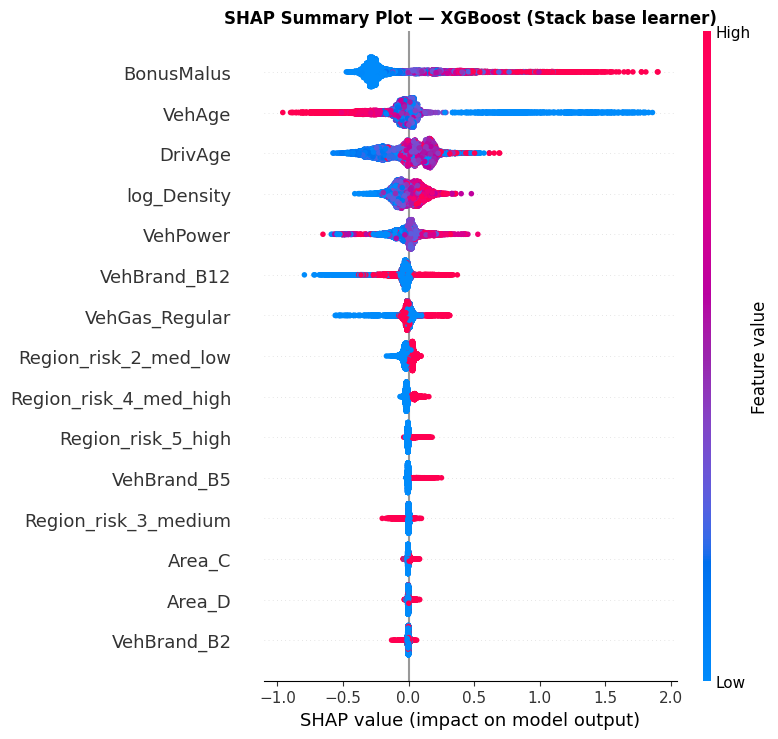

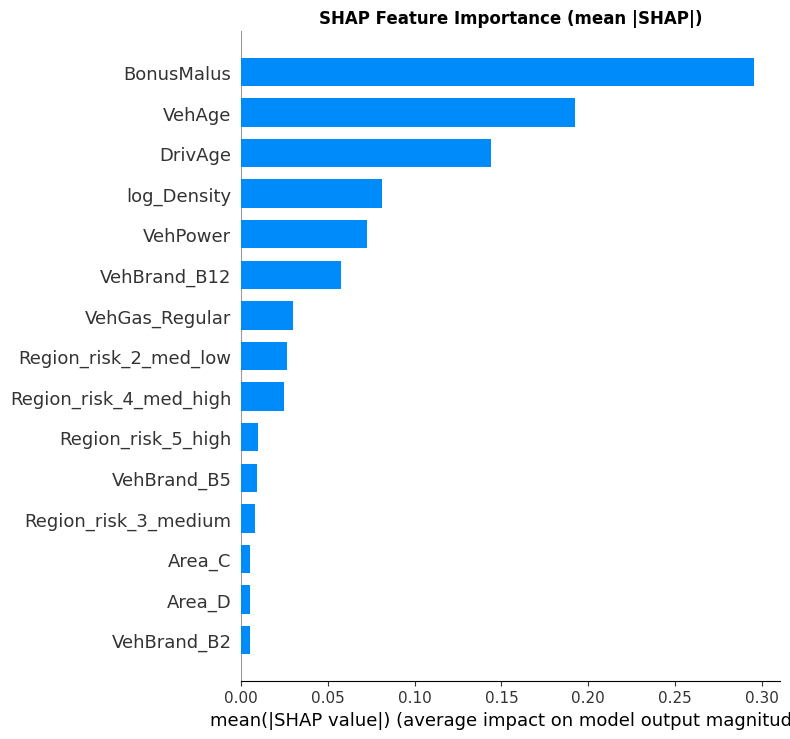

In [74]:
#mean |SHAP| for every feture
shap_importance = pd.DataFrame({
    "feature": X_test_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_shap":     shap_values.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Global feature importance (mean |SHAP|):")
print(shap_importance.to_string(index=False))

# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="dot",
    max_display=15,
    show=False)

plt.title("SHAP Summary Plot — XGBoost (Stack base learner)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# SHAP bar plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",
    max_display=15,
    show=False)

plt.title("SHAP Feature Importance (mean |SHAP|)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

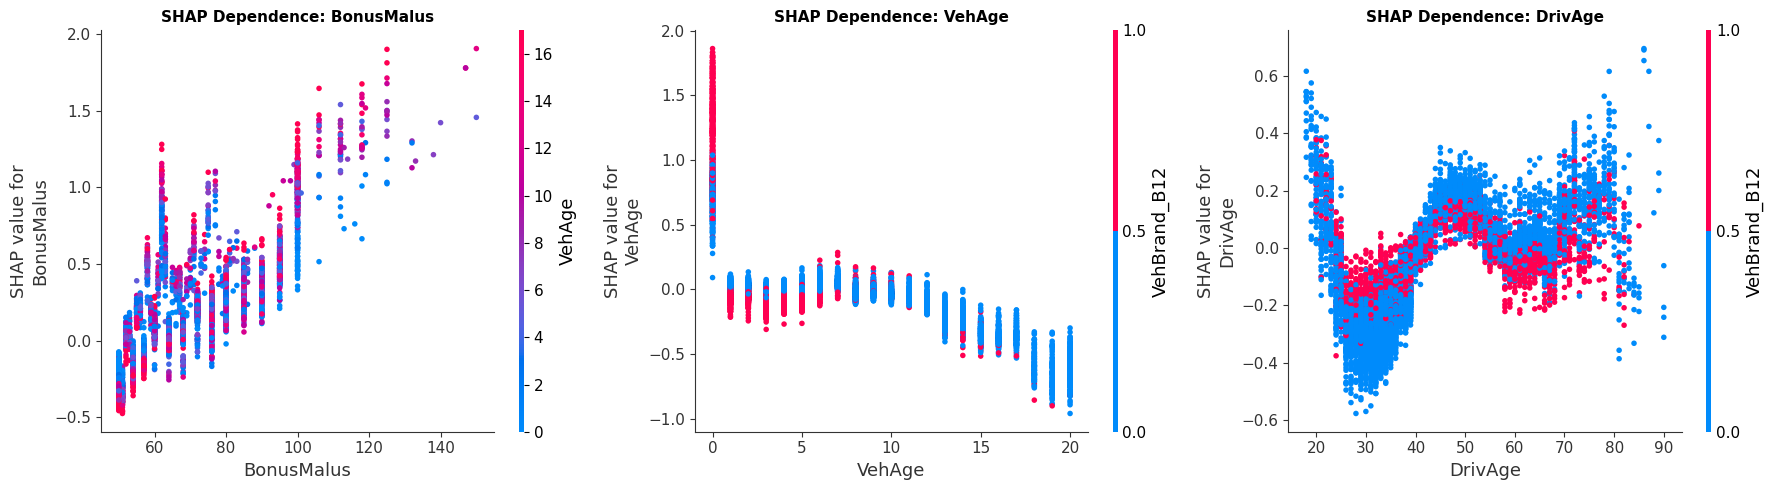

In [75]:
# Dependence plots top-3 features
features_to_plot = ["BonusMalus", "VehAge", "DrivAge"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(features_to_plot):
    shap.dependence_plot(
        feat,
        shap_values,
        X_test_sample,
        ax=axes[i],
        show=False,
        interaction_index="auto")

    axes[i].set_title(f"SHAP Dependence: {feat}", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

# Final results

In [96]:
final_results = pd.DataFrame(all_results)
final_results = final_results.drop_duplicates(subset=["model", "split"], keep="last")

test_results = (
    final_results[final_results["split"] == "Test"]
    .reset_index(drop=True)
    .copy())

test_results = test_results.sort_values("gini", ascending=False).reset_index(drop=True)

def categorize(model_name):
    if "Stack" in model_name:
        return "Stacking"
    elif "Forest" in model_name:
        return "Bagging"
    elif "XGBoost" in model_name:
        return "Boosting"
    else:
        return "GLM"

test_results["family"] = test_results["model"].apply(categorize)

final_table = test_results[["family", "model", "poisson_deviance", "mae", "gini"]].copy()
final_table.columns = ["Family", "Model", "Poisson Deviance", "MAE", "Gini"]

print("Final model comparison on test set")
print(final_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Final model comparison on test set
  Family              Model  Poisson Deviance    MAE   Gini
Stacking Stack (ZIP+RF+XGB)            0.2966 0.0981 0.3643
Boosting    XGBoost (tuned)            0.3024 0.0963 0.3629
Boosting      XGBoost (reg)            0.3031 0.0966 0.3599
Boosting            XGBoost            0.3032 0.0966 0.3596
 Bagging      Random Forest            0.3081 0.0981 0.3268
     GLM               ZINB            0.3207 0.0996 0.2611
     GLM                ZIP            0.3203 0.0998 0.2609
     GLM        Poisson GLM            0.3216 0.0992 0.2528
     GLM             NB GLM            0.3216 0.0997 0.2528


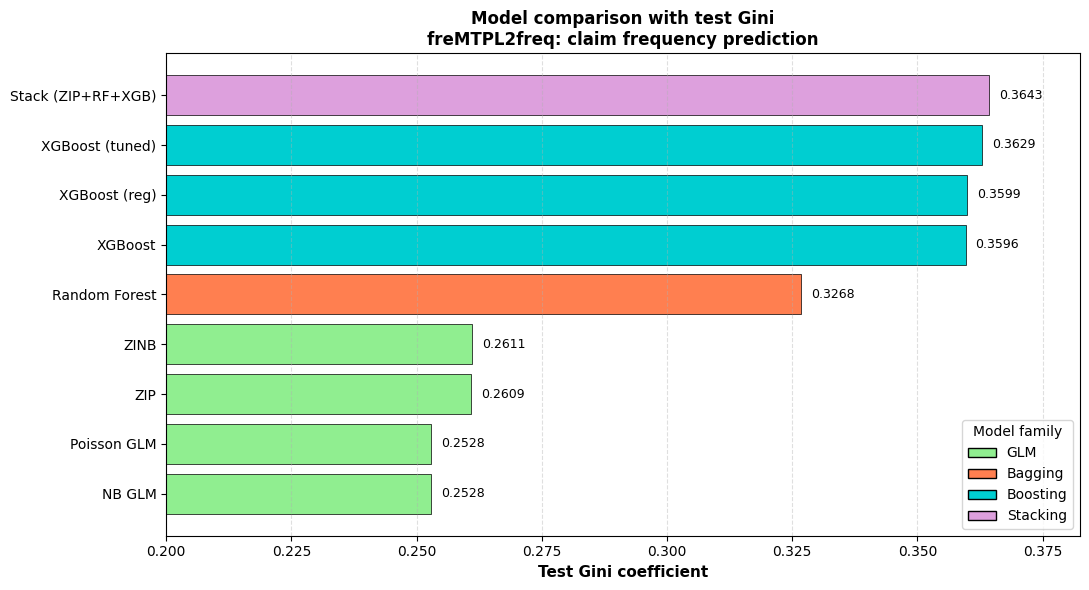

In [97]:
fig, ax = plt.subplots(figsize=(11, 6))

family_colors = {
    "GLM": "lightgreen",
    "Bagging":  "coral",
    "Boosting": "darkturquoise",
    "Stacking": "plum"}

colors = [family_colors[f] for f in test_results["family"]]

bars = ax.barh(
    test_results["model"][::-1],
    test_results["gini"][::-1],
    color=colors[::-1],
    edgecolor="black",
    linewidth=0.5)

for bar, val in zip(bars, test_results["gini"][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlabel("Test Gini coefficient", fontsize=11, fontweight="bold")
ax.set_title("Model comparison with test Gini\nfreMTPL2freq: claim frequency prediction",
             fontsize=12, fontweight="bold")
ax.set_xlim(0.20, max(test_results["gini"]) * 1.05)
ax.grid(axis="x", linestyle="--", alpha=0.4)

legend_elements = [Patch(facecolor=color, edgecolor="black", label=family)
                   for family, color in family_colors.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10, title="Model family")

plt.tight_layout()
plt.show()

**Key findings**:
1. Tree-based models capture around 38% more risk discrimination (Gini) than GLM.
2. Stacking yields marginal Gini improvement over XGBoost (+0.5%).
3. SHAP reveals U-shape DrivAge effect and not obvious VehAge pattern, both inaccessible to linear specifications.